In [ ]:
import sys
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import requests
import bs4 as bs
from tqdm import tqdm
from IPython.display import clear_output
import time
import random
from sklearn.preprocessing import MinMaxScaler

import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [ ]:
file_path = '/content/makam.xlsx'
df = pd.read_excel(file_path)

In [ ]:
df.tail(5)

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),TDS\n(mg/L),Salinity\n(g/L),DO\n(mg/L),Sensor Depth\n(m),pH,Chlorophyll\n(ug/L),Turbid\n(NTU)
538748,2024-07-25 22:00:00,30.72,260.0,166.5,0.12,3.27,2.02,0.0,6.70,49.64
538749,2024-07-25 22:10:00,30.71,260.0,166.4,0.12,3.35,2.06,0.0,5.86,40.77
538750,2024-07-25 22:20:00,30.71,258.0,165.5,0.12,3.24,2.10,0.0,2.97,55.74
538751,2024-07-25 22:30:00,30.71,258.0,165.3,0.12,3.30,2.13,0.0,5.18,47.67
538752,2024-07-25 22:40:00,30.72,258.0,165.4,0.12,3.33,2.16,0.0,5.48,48.79


In [ ]:
df = df.drop(['TDS\n(mg/L)'], axis=1)
df = df.drop(['Salinity\n(g/L)'], axis=1)
df = df.drop(['Sensor Depth\n(m)'], axis=1)
df = df.drop(['Chlorophyll\n(ug/L)'], axis=1)
df = df.drop(['Turbid\n(NTU)'], axis=1)

In [ ]:
df

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
0,2014-04-28 14:40:00,28.93,0.0,7.87,9.34
1,2014-04-28 14:50:00,NaN,NaN,NaN,NaN
2,2014-04-28 15:00:00,NaN,NaN,NaN,NaN
3,2014-04-28 15:10:00,NaN,NaN,NaN,NaN
4,2014-04-28 15:20:00,NaN,NaN,NaN,NaN
...,...,...,...,...,...
538748,2024-07-25 22:00:00,30.72,260.0,3.27,0.00
538749,2024-07-25 22:10:00,30.71,260.0,3.35,0.00
538750,2024-07-25 22:20:00,30.71,258.0,3.24,0.00
538751,2024-07-25 22:30:00,30.71,258.0,3.30,0.00


# **clean data**:

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,432899.000000,432899.000000,432899.000000,432899.000000
mean,2019-06-12 06:39:59.999998464,-78.213296,349.596384,-210.651016,-398.025160
min,2014-04-28 14:40:00,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,2016-11-18 22:40:00,29.140000,294.000000,1.630000,7.120000
50%,2019-06-12 06:40:00,30.550000,356.000000,2.720000,7.230000
75%,2022-01-02 14:40:00,31.410000,440.000000,3.600000,7.340000
max,2024-07-25 22:40:00,99.990000,7816.000000,11.470000,50.840000
std,NaN,1037.028654,1173.119092,1445.086492,1972.434922


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),105854
Conductivity\n(uS/cm),105854
DO\n(mg/L),105854
pH,105854


In [ ]:
# ตรวจสอบค่า -9999 ในทุกคอลัมน์
neg9999_counts = (df == -9999).sum()
print(neg9999_counts)

date_time                    0
Temperature\n(֯C)         4679
Conductivity\n(uS/cm)     4658
DO\n(mg/L)                9234
pH                       17531
dtype: int64


In [ ]:
df = df.replace(-9999, np.nan)

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,428220.000000,428241.000000,423665.000000,415368.000000
mean,2019-06-12 06:39:59.999998464,30.187435,462.158614,2.691163,7.193080
min,2014-04-28 14:40:00,0.000000,-3999.000000,0.000000,-26.300000
25%,2016-11-18 22:40:00,29.190000,297.000000,1.730000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.760000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.620000,7.350000
max,2024-07-25 22:40:00,99.990000,7816.000000,11.470000,50.840000
std,NaN,2.339895,462.215793,1.578567,0.650542


In [ ]:
# ตรวจสอบค่า 0 ในทุกคอลัมน์
zero_counts = (df == 0).sum()
print(zero_counts)

date_time                    0
Temperature\n(֯C)          597
Conductivity\n(uS/cm)     2263
DO\n(mg/L)               42510
pH                        2794
dtype: int64


In [ ]:
df = df.replace(0, np.nan)

In [ ]:
zero_counts = (df == 50.840000).sum()
print(zero_counts)

date_time                0
Temperature\n(֯C)        0
Conductivity\n(uS/cm)    0
DO\n(mg/L)               0
pH                       1
dtype: int64


In [ ]:
df = df.replace(50.840000, np.nan)

In [ ]:
zero_counts = (df == -26.300000).sum()
print(zero_counts)

date_time                0
Temperature\n(֯C)        0
Conductivity\n(uS/cm)    0
DO\n(mg/L)               0
pH                       1
dtype: int64


In [ ]:
df = df.replace(-26.300000, np.nan)

In [ ]:
zero_counts = (df == -3999.000000).sum()
print(zero_counts)

date_time                 0
Temperature\n(֯C)         0
Conductivity\n(uS/cm)    87
DO\n(mg/L)                0
pH                        0
dtype: int64


In [ ]:
df = df.replace(-3999.000000, np.nan)

In [ ]:
zero_counts = (df == 99.990000).sum()
print(zero_counts)

date_time                  0
Temperature\n(֯C)        105
Conductivity\n(uS/cm)      0
DO\n(mg/L)                 0
pH                         0
dtype: int64


In [ ]:
df = df.replace(99.990000, np.nan)

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425891.000000,381155.000000,412572.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.525639,2.991307,7.241768
min,2014-04-28 14:40:00,12.830000,1.000000,0.010000,-15.340000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,29.530000
std,NaN,1.736159,457.832389,1.368198,0.256849


In [ ]:
df['Conductivity\n(uS/cm)'][df['Conductivity\n(uS/cm)'] < 100] = np.nan
df['pH'][df['pH'] < 1] = np.nan

<ipython-input-116-096c18d0bb55>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Conductivity\n(uS/cm)'][df['Conductivity\n(uS/cm)'] < 100] = np.nan
<ipython-input-116-096c18d0bb55>:1: SettingWithCopyWarning: 
A value is trying to be se

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425815.000000,381155.000000,412556.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.605225,2.991307,7.242067
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,29.530000
std,NaN,1.736159,457.834400,1.368198,0.251171


In [ ]:
df['pH'][df['pH'] > 14] = np.nan

<ipython-input-118-796f110e6a72>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['pH'][df['pH'] > 14] = np.nan
<ipython-input-118-796f110e6a72>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,427518.000000,425815.000000,381155.000000,412552.000000
mean,2019-06-12 06:39:59.999998464,30.212446,465.605225,2.991307,7.241943
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.200000,299.000000,2.100000,7.130000
50%,2019-06-12 06:40:00,30.570000,358.000000,2.930000,7.240000
75%,2022-01-02 14:40:00,31.420000,442.000000,3.710000,7.350000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.736159,457.834400,1.368198,0.247345


In [ ]:
df['Temperature\n(֯C)'].interpolate(method='linear', inplace=True)
df['Conductivity\n(uS/cm)'].interpolate(method='linear', inplace=True)
df['DO\n(mg/L)'].interpolate(method='linear', inplace=True)
df['pH'].interpolate(method='linear', inplace=True)

<ipython-input-120-b4db06670e76>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Temperature\n(֯C)'].interpolate(method='linear', inplace=True)
<ipython-input-120-b4db06670e76>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,538753.000000,536313.000000,538753.000000,538753.000000
mean,2019-06-12 06:39:59.999998464,30.083002,501.199898,2.964049,7.236434
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.151753,315.000000,2.290000,7.160000
50%,2019-06-12 06:40:00,30.200000,381.000000,2.905802,7.260000
75%,2022-01-02 14:40:00,31.250000,524.967900,3.490000,7.340000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.616849,426.525651,1.217890,0.353856


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),2440
DO\n(mg/L),0
pH,0


In [ ]:
df['Conductivity\n(uS/cm)'].fillna(df['Conductivity\n(uS/cm)'].mean(), inplace=True)

<ipython-input-123-0624677d0968>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Conductivity\n(uS/cm)'].fillna(df['Conductivity\n(uS/cm)'].mean(), inplace=True)


In [ ]:
df.isnull().sum()

,0
date_time,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),0
DO\n(mg/L),0
pH,0


In [ ]:
df.describe()

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH
count,538753,538753.000000,538753.000000,538753.000000,538753.000000
mean,2019-06-12 06:39:59.999998464,30.083002,501.199898,2.964049,7.236434
min,2014-04-28 14:40:00,12.830000,120.000000,0.010000,1.000000
25%,2016-11-18 22:40:00,29.151753,315.000000,2.290000,7.160000
50%,2019-06-12 06:40:00,30.200000,381.654009,2.905802,7.260000
75%,2022-01-02 14:40:00,31.250000,523.263959,3.490000,7.340000
max,2024-07-25 22:40:00,36.730000,7816.000000,11.470000,9.690000
std,NaN,1.616849,425.558691,1.217890,0.353856


In [ ]:
# แปลงคอลัมน์ date_time เป็น datetime format
df['date_time'] = pd.to_datetime(df['date_time'])

In [ ]:
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year

In [ ]:
df

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,day,month,year
0,2014-04-28 14:40:00,28.930000,501.199898,7.870000,9.340000,28,4,2014
1,2014-04-28 14:50:00,28.933946,501.199898,7.865893,9.337691,28,4,2014
2,2014-04-28 15:00:00,28.937893,501.199898,7.861785,9.335383,28,4,2014
3,2014-04-28 15:10:00,28.941839,501.199898,7.857678,9.333074,28,4,2014
4,2014-04-28 15:20:00,28.945785,501.199898,7.853570,9.330765,28,4,2014
...,...,...,...,...,...,...,...,...
538748,2024-07-25 22:00:00,30.720000,260.000000,3.270000,3.080000,25,7,2024
538749,2024-07-25 22:10:00,30.710000,260.000000,3.350000,3.080000,25,7,2024
538750,2024-07-25 22:20:00,30.710000,258.000000,3.240000,3.080000,25,7,2024
538751,2024-07-25 22:30:00,30.710000,258.000000,3.300000,3.080000,25,7,2024


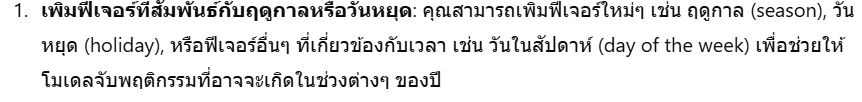

In [ ]:
df['season'] = df['month'].apply(lambda x: (x%12 + 3)//3)

In [ ]:
df

,date_time,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,day,month,year,season
0,2014-04-28 14:40:00,28.930000,501.199898,7.870000,9.340000,28,4,2014,2
1,2014-04-28 14:50:00,28.933946,501.199898,7.865893,9.337691,28,4,2014,2
2,2014-04-28 15:00:00,28.937893,501.199898,7.861785,9.335383,28,4,2014,2
3,2014-04-28 15:10:00,28.941839,501.199898,7.857678,9.333074,28,4,2014,2
4,2014-04-28 15:20:00,28.945785,501.199898,7.853570,9.330765,28,4,2014,2
...,...,...,...,...,...,...,...,...,...
538748,2024-07-25 22:00:00,30.720000,260.000000,3.270000,3.080000,25,7,2024,3
538749,2024-07-25 22:10:00,30.710000,260.000000,3.350000,3.080000,25,7,2024,3
538750,2024-07-25 22:20:00,30.710000,258.000000,3.240000,3.080000,25,7,2024,3
538751,2024-07-25 22:30:00,30.710000,258.000000,3.300000,3.080000,25,7,2024,3


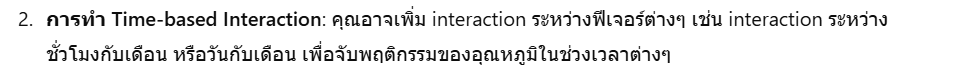

In [ ]:
df['day_month_interaction'] = df['day'] * df['month']

In [ ]:
df = df.set_index('date_time')

In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,day,month,year,season,day_month_interaction
date_time,,,,,,,,,
2014-04-28 14:40:00,28.930000,501.199898,7.870000,9.340000,28,4,2014,2,112
2014-04-28 14:50:00,28.933946,501.199898,7.865893,9.337691,28,4,2014,2,112
2014-04-28 15:00:00,28.937893,501.199898,7.861785,9.335383,28,4,2014,2,112
2014-04-28 15:10:00,28.941839,501.199898,7.857678,9.333074,28,4,2014,2,112
2014-04-28 15:20:00,28.945785,501.199898,7.853570,9.330765,28,4,2014,2,112
...,...,...,...,...,...,...,...,...,...
2024-07-25 22:00:00,30.720000,260.000000,3.270000,3.080000,25,7,2024,3,175
2024-07-25 22:10:00,30.710000,260.000000,3.350000,3.080000,25,7,2024,3,175
2024-07-25 22:20:00,30.710000,258.000000,3.240000,3.080000,25,7,2024,3,175


In [ ]:
df = df.resample('D').mean()

In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,day,month,year,season,day_month_interaction
date_time,,,,,,,,,
2014-04-28,29.038523,501.199898,7.757047,9.276510,28.0,4.0,2014.0,2.0,112.0
2014-04-29,29.433154,501.199898,7.346309,9.045638,29.0,4.0,2014.0,2.0,116.0
2014-04-30,30.001423,501.199898,6.754846,8.713181,30.0,4.0,2014.0,2.0,120.0
2014-05-01,30.569691,501.199898,6.163383,8.380725,1.0,5.0,2014.0,2.0,5.0
2014-05-02,31.137960,501.199898,5.571919,8.048268,2.0,5.0,2014.0,2.0,10.0
...,...,...,...,...,...,...,...,...,...
2024-07-21,31.365139,351.027778,2.146181,3.080000,21.0,7.0,2024.0,3.0,147.0
2024-07-22,31.287986,345.090278,2.114375,3.080000,22.0,7.0,2024.0,3.0,154.0
2024-07-23,31.137361,338.798611,2.126111,3.080000,23.0,7.0,2024.0,3.0,161.0


## ใส่ข้อมูลย้อนหลังของข้อมูลต่างๆ7วัน

In [ ]:
df['temp_lag_1'] = df['Temperature\n(֯C)'].shift(1)
df['temp_lag_2'] = df['Temperature\n(֯C)'].shift(2)
df['temp_lag_3'] = df['Temperature\n(֯C)'].shift(3)
df['temp_lag_4'] = df['Temperature\n(֯C)'].shift(4)
df['temp_lag_5'] = df['Temperature\n(֯C)'].shift(5)
df['temp_lag_6'] = df['Temperature\n(֯C)'].shift(6)
df['temp_lag_7'] = df['Temperature\n(֯C)'].shift(7)

In [ ]:
df['EC_lag_1'] = df['Conductivity\n(uS/cm)'].shift(1)
df['EC_lag_2'] = df['Conductivity\n(uS/cm)'].shift(2)
df['EC_lag_3'] = df['Conductivity\n(uS/cm)'].shift(3)
df['EC_lag_4'] = df['Conductivity\n(uS/cm)'].shift(4)
df['EC_lag_5'] = df['Conductivity\n(uS/cm)'].shift(5)
df['EC_lag_6'] = df['Conductivity\n(uS/cm)'].shift(6)
df['EC_lag_7'] = df['Conductivity\n(uS/cm)'].shift(7)

In [ ]:
df['DO_lag_1'] = df['DO\n(mg/L)'].shift(1)
df['DO_lag_2'] = df['DO\n(mg/L)'].shift(2)
df['DO_lag_3'] = df['DO\n(mg/L)'].shift(3)
df['DO_lag_4'] = df['DO\n(mg/L)'].shift(4)
df['DO_lag_5'] = df['DO\n(mg/L)'].shift(5)
df['DO_lag_6'] = df['DO\n(mg/L)'].shift(6)
df['DO_lag_7'] = df['DO\n(mg/L)'].shift(7)

In [ ]:
df['pH_lag_1'] = df['pH'].shift(1)
df['pH_lag_2'] = df['pH'].shift(2)
df['pH_lag_3'] = df['pH'].shift(3)
df['pH_lag_4'] = df['pH'].shift(4)
df['pH_lag_5'] = df['pH'].shift(5)
df['pH_lag_6'] = df['pH'].shift(6)
df['pH_lag_7'] = df['pH'].shift(7)

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.describe()

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,day,month,year,season,day_month_interaction,temp_lag_1,...,DO_lag_5,DO_lag_6,DO_lag_7,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
count,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,...,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000,3735.000000
mean,30.082045,501.197132,2.958886,7.234540,15.727711,6.510308,2018.953949,2.506560,102.663722,30.082278,...,2.963094,2.964452,2.965889,7.235749,7.236989,7.238320,7.239739,7.241247,7.242844,7.244503
std,1.605010,359.688885,1.104246,0.341453,8.789268,3.414239,2.977423,1.105034,84.512410,1.605182,...,1.108521,1.110782,1.113507,0.334666,0.327774,0.320908,0.314164,0.307642,0.301456,0.295533
min,20.238053,164.506944,0.233403,2.082611,1.000000,1.000000,2014.000000,1.000000,1.000000,20.238053,...,0.233403,0.233403,0.233403,2.082611,2.082611,2.082611,2.082611,2.082611,2.082611,2.082611
25%,29.155264,318.267361,2.328314,7.160365,8.000000,4.000000,2016.000000,2.000000,32.000000,29.155264,...,2.333437,2.333933,2.333933,7.160399,7.160450,7.160693,7.160972,7.161042,7.161042,7.161042
50%,30.205035,385.791667,2.904792,7.261667,16.000000,6.000000,2019.000000,3.000000,80.000000,30.205035,...,2.907847,2.908403,2.908436,7.261667,7.261701,7.261806,7.261883,7.262083,7.262099,7.262153
75%,31.246146,540.576941,3.460035,7.339792,23.000000,9.000000,2022.000000,3.000000,154.000000,31.246771,...,3.466076,3.469230,3.470827,7.339826,7.339896,7.339966,7.340035,7.340143,7.340234,7.340342
max,34.226458,4057.263889,7.837917,8.270000,31.000000,12.000000,2024.000000,4.000000,372.000000,34.226458,...,7.837917,7.837917,7.837917,8.270000,8.270000,8.270000,8.380725,8.713181,9.045638,9.276510


#**Temp**

In [ ]:
X = df[['temp_lag_1','temp_lag_2','temp_lag_3','temp_lag_4','temp_lag_5','temp_lag_6','temp_lag_7']]
y = df["Temperature\n(֯C)"]

In [ ]:
y

,Temperature\n(֯C)
date_time,
2014-05-05,31.747917
2014-05-06,31.799965
2014-05-07,31.775764
2014-05-08,31.948542
2014-05-09,32.087292
...,...
2024-07-21,31.365139
2024-07-22,31.287986
2024-07-23,31.137361


In [ ]:
X

,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_5,temp_lag_6,temp_lag_7
date_time,,,,,,,
2014-05-05,31.693750,31.678415,31.137960,30.569691,30.001423,29.433154,29.038523
2014-05-06,31.747917,31.693750,31.678415,31.137960,30.569691,30.001423,29.433154
2014-05-07,31.799965,31.747917,31.693750,31.678415,31.137960,30.569691,30.001423
2014-05-08,31.775764,31.799965,31.747917,31.693750,31.678415,31.137960,30.569691
2014-05-09,31.948542,31.775764,31.799965,31.747917,31.693750,31.678415,31.137960
...,...,...,...,...,...,...,...
2024-07-21,31.311667,31.264444,31.348333,31.361736,31.442431,31.555000,31.562153
2024-07-22,31.365139,31.311667,31.264444,31.348333,31.361736,31.442431,31.555000
2024-07-23,31.287986,31.365139,31.311667,31.264444,31.348333,31.361736,31.442431


In [ ]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#X = scaler.fit_transform(X)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y = pd.DataFrame(y_scaled, columns=[y.name], index=y.index)

In [ ]:
X

,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_5,temp_lag_6,temp_lag_7
date_time,,,,,,,
2014-05-05,0.818942,0.817846,0.779210,0.738586,0.697962,0.657337,0.629126
2014-05-06,0.822815,0.818942,0.817846,0.779210,0.738586,0.697962,0.657337
2014-05-07,0.826535,0.822815,0.818942,0.817846,0.779210,0.738586,0.697962
2014-05-08,0.824805,0.826535,0.822815,0.818942,0.817846,0.779210,0.738586
2014-05-09,0.837157,0.824805,0.826535,0.822815,0.818942,0.817846,0.779210
...,...,...,...,...,...,...,...
2024-07-21,0.791628,0.788252,0.794249,0.795207,0.800976,0.809023,0.809535
2024-07-22,0.795451,0.791628,0.788252,0.794249,0.795207,0.800976,0.809023
2024-07-23,0.789935,0.795451,0.791628,0.788252,0.794249,0.795207,0.800976


In [ ]:
y

,Temperature\n(֯C)
date_time,
2014-05-05,0.822815
2014-05-06,0.826535
2014-05-07,0.824805
2014-05-08,0.837157
2014-05-09,0.847076
...,...
2024-07-21,0.795451
2024-07-22,0.789935
2024-07-23,0.779167


In [ ]:
split_at = int(len(X) * 0.7)

In [ ]:
# ช่วงที่ 1
X_train1, X_test1 = X[:split_at], X[split_at:]
y_train1, y_test1 = y[:split_at], y[split_at:]

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 22.2 MB/s eta 0:00:00



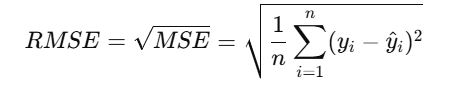




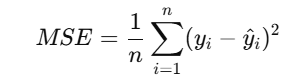






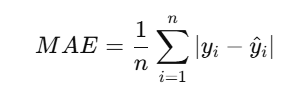








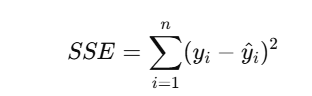



**note**

1. SSE (Sum of Squared Errors)ได้จากการนำเอาผลต่างระหว่างค่าที่ทำนายกับคำตอบจริงของแต่ละตัวอย่างมายกกำลังสอง แล้วนำมาบวกกันทั้งหมด (machine learning)
2. MAE (Mean Absolute Error) ได้จากการนำ SSE มาหารจำนวนตัวอย่าง
3. RMSE (Root Mean Square Error) คือ วิธีการวัดความแตกต่างระหว่างค่าที่คาดการณ์และค่าจริง โดยการหาค่ารากที่สองของค่าเฉลี่ยของความผิดพลาดกำลังสอง (squared errors)
4. MSE (Mean Squared Error) คือ วิธีการวัดความแตกต่างระหว่างค่าที่คาดการณ์และค่าจริง โดยจะคำนวณค่าผิดพลาดกำลังสอง (squared errors) และหาค่าเฉลี่ย



***SSE บ่งบอกถึงผลรวมของข้อผิดพลาดทั้งหมด หากมีจำนวนข้อมูลมาก ค่า SSE มักจะสูงได้โดยธรรมชาติ

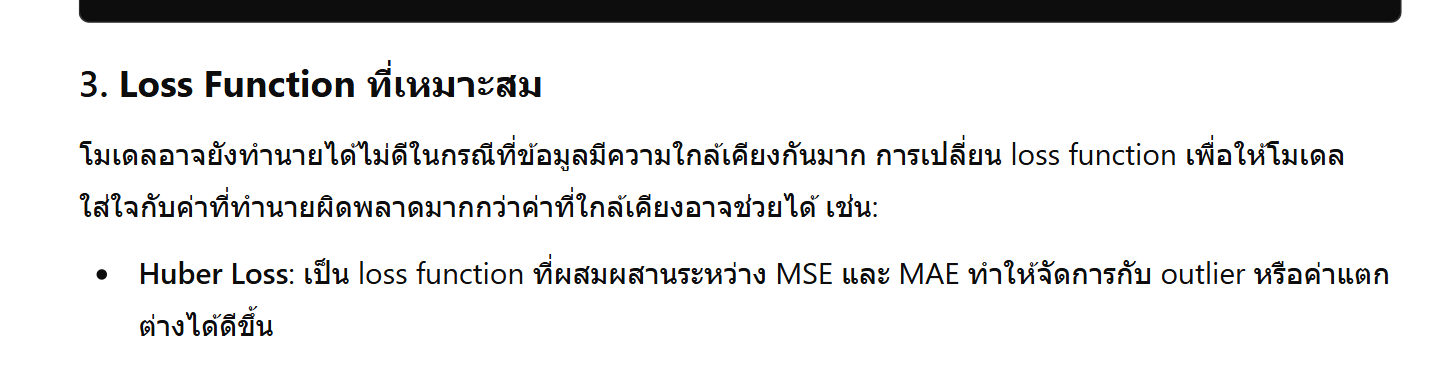

In [ ]:
import optuna
from optuna.samplers import TPESampler

def regression_model(clf, X_train, y_train, X_test, y_test, show_feature_importance=True):
    clf_model = clf.fit(X_train, y_train)

    y_hat_train = clf_model.predict(X_train)
    y_hat_test = clf_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_hat_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_hat_test))
    mse = mean_squared_error(y_test, y_hat_test)
    train_r2 = r2_score(y_test, y_hat_test)

    print('Test set performance:\n')
    print(f'R2: {train_r2}')
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')
    print(f'MSE: {mse}\n')

    if show_feature_importance:
        feature_importances = clf_model.feature_importances_
        feature_df = pd.DataFrame({
            "Feature": pd.DataFrame(X_train).columns,
            "Importance": feature_importances
        }).sort_values(by="Importance", ascending=False)
        print("\nความสำคัญของตัวแปร:\n", feature_df)

    return y_hat_test

# Loss Function
def huber_approx_obj(preds, dtrain):
    d = preds - dtrain.get_label()
    h = 1
    scale = 1 + (d / h)**2
    grad = d / scale
    hess = 1 / scale
    return grad, hess

# Objective สำหรับ Optuna
def objective(trial):
    param = {
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
        'max_depth': trial.suggest_int('max_depth', 3, 6),  # ความลึกของต้นไม้
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),  # จำนวนต้นไม้
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 10),  #  min_child_weight
        'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.4, 0.6),  #  colsample_bytree
        'gamma': trial.suggest_loguniform('gamma', 0.5, 1.0),  #  gamma
        'alpha': trial.suggest_loguniform('alpha', 1e-5, 1e-2),  #  L1 regularization
        'lambda': trial.suggest_loguniform('lambda', 1e-5, 1e-2),  # L2 regularization
        'random_state': 0
    }

    # สร้างโมเดล XGBoost ด้วย Custom Huber Loss
    model = xgb.train(param, xgb.DMatrix(X_train1, label=y_train1), obj=huber_approx_obj)
    y_pred = model.predict(xgb.DMatrix(X_test1))
    mse = mean_squared_error(y_test1, y_pred)
    return mse

## no**.1**

In [ ]:

study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)


print("Best hyperparameters: ", study.best_params)


best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)


regression_model(best_xgb_regressor, X_train1, y_train1, X_test1, y_test1)

[I 2025-05-06 19:27:00,321] A new study created in memory with name: no-name-47c608d3-7354-4db1-b10b-baec698591eb
<ipython-input-54-065764a7206d>:43: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
<ipython-input-54-065764a7206d>:47: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
<ipython-input-54-065764a7206d>:48: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.s

Best hyperparameters:  {'learning_rate': 0.04994753403702507, 'max_depth': 3, 'n_estimators': 147, 'min_child_weight': 9, 'subsample': 0.5214065735528597, 'colsample_bytree': 0.5105955333043001, 'gamma': 0.5703784481220963, 'alpha': 1.0141878371654794e-05, 'lambda': 1.0155071874970074e-05}
Test set performance:

R2: 0.8267906308174133
MAE: 0.03457598760724068
RMSE: 0.05469574610665363
MSE: 0.002991624642163515


ความสำคัญของตัวแปร:
       Feature  Importance
3  temp_lag_4    0.354059
1  temp_lag_2    0.239836
2  temp_lag_3    0.216751
0  temp_lag_1    0.189354
4  temp_lag_5    0.000000
5  temp_lag_6    0.000000
6  temp_lag_7    0.000000


array([0.7943958 , 0.7943958 , 0.8013339 , ..., 0.7811043 , 0.77842677,
       0.7665053 ], dtype=float32)

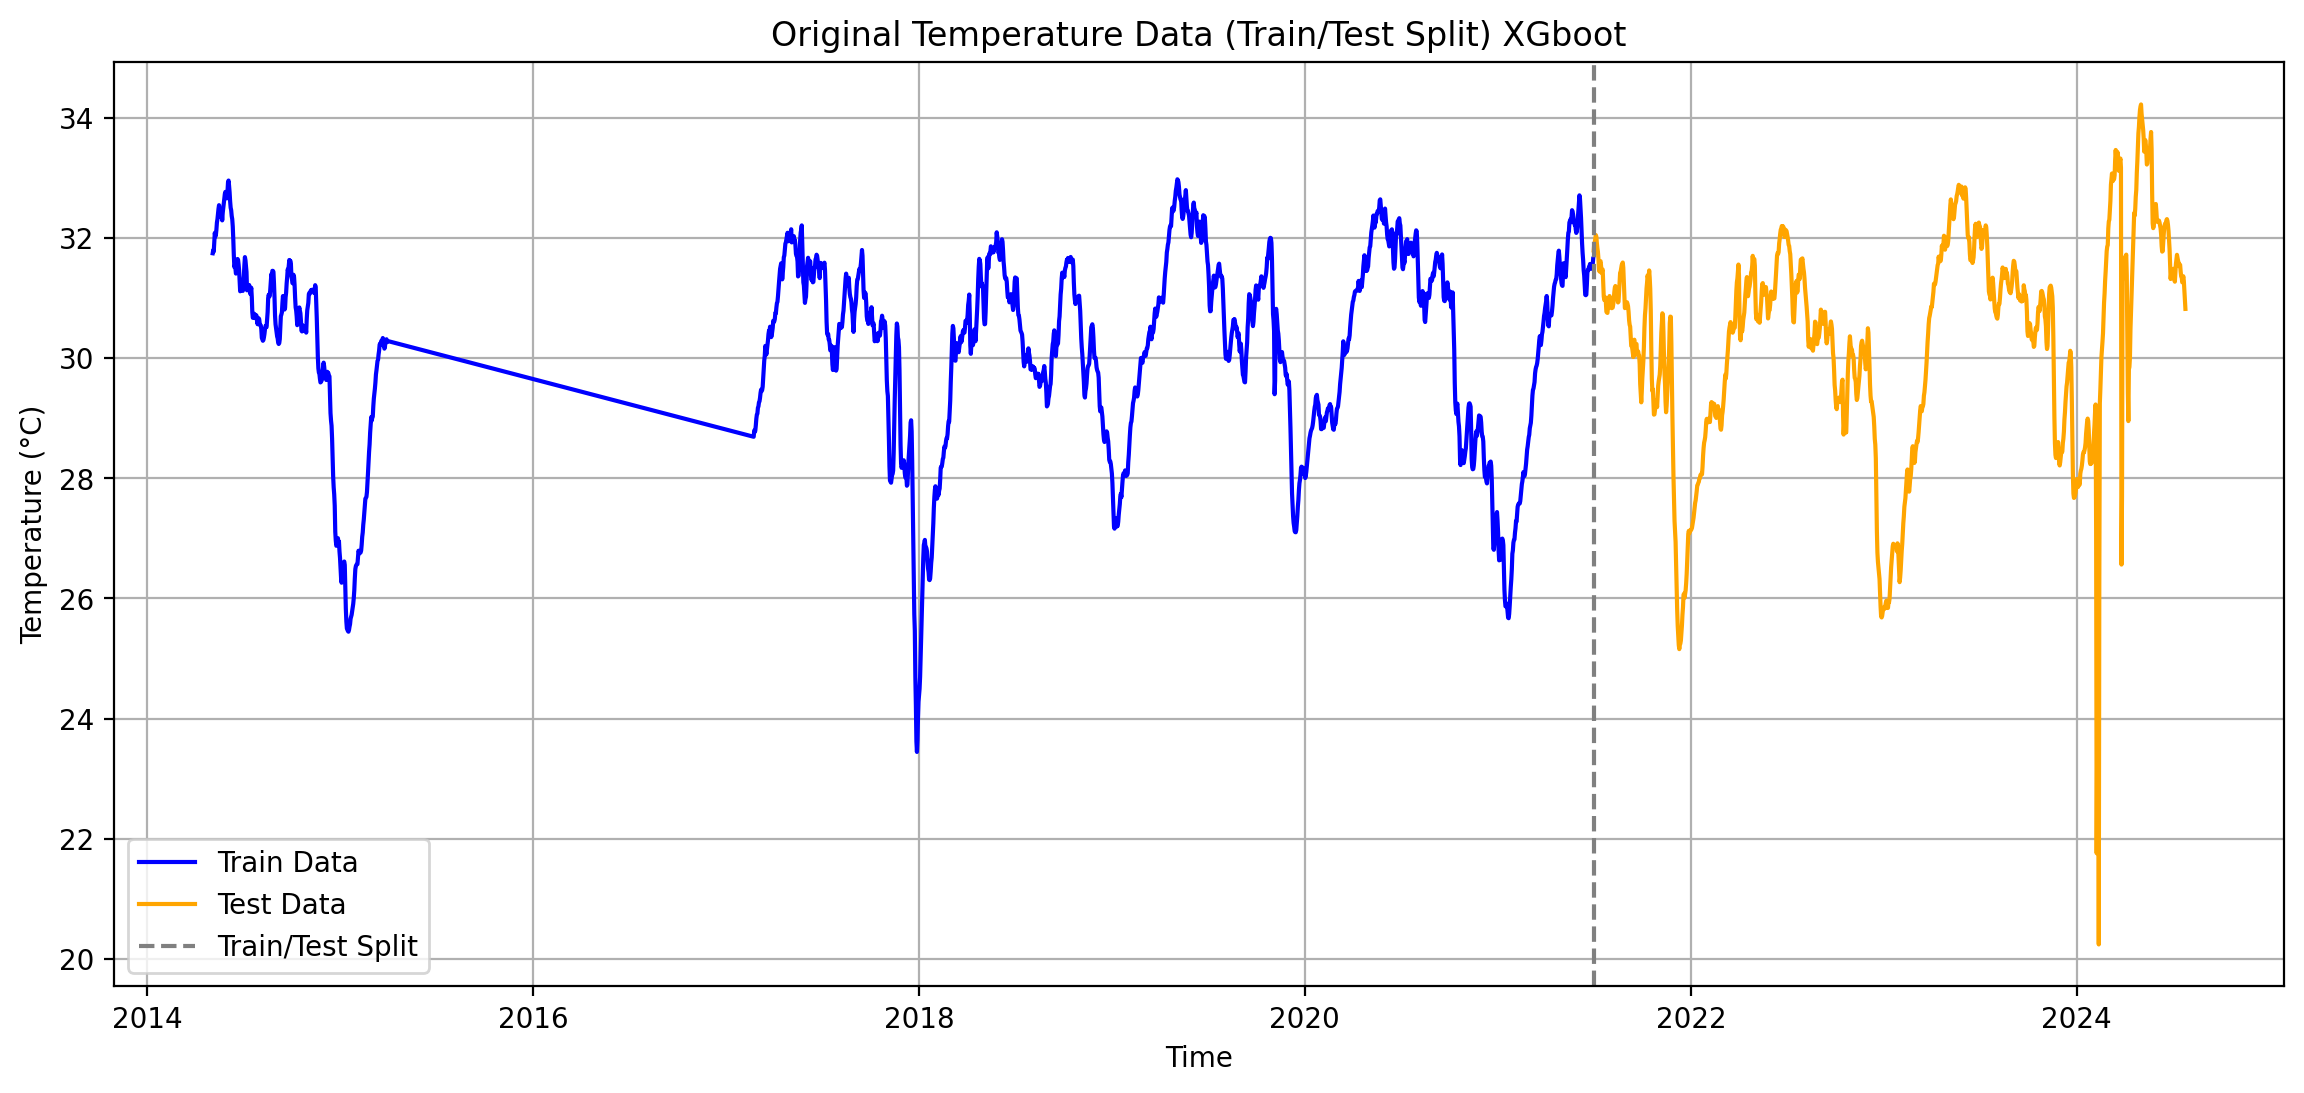

In [ ]:
plt.figure(figsize=(14, 6))
y_inv = scaler.inverse_transform(y) #กลับค่า y เป็นสเกลจริง

y_train_inv = y_inv[:split_at]
y_test_inv = y_inv[split_at:]

plt.plot(y.index[:split_at], y_train_inv, label="Train Data", color='blue')
plt.plot(y.index[split_at:], y_test_inv, label="Test Data", color='orange')
plt.axvline(x=y.index[split_at], color='gray', linestyle='--', label='Train/Test Split') #เส้นเเบ่ง
plt.title("Original Temperature Data (Train/Test Split) XGboot")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()


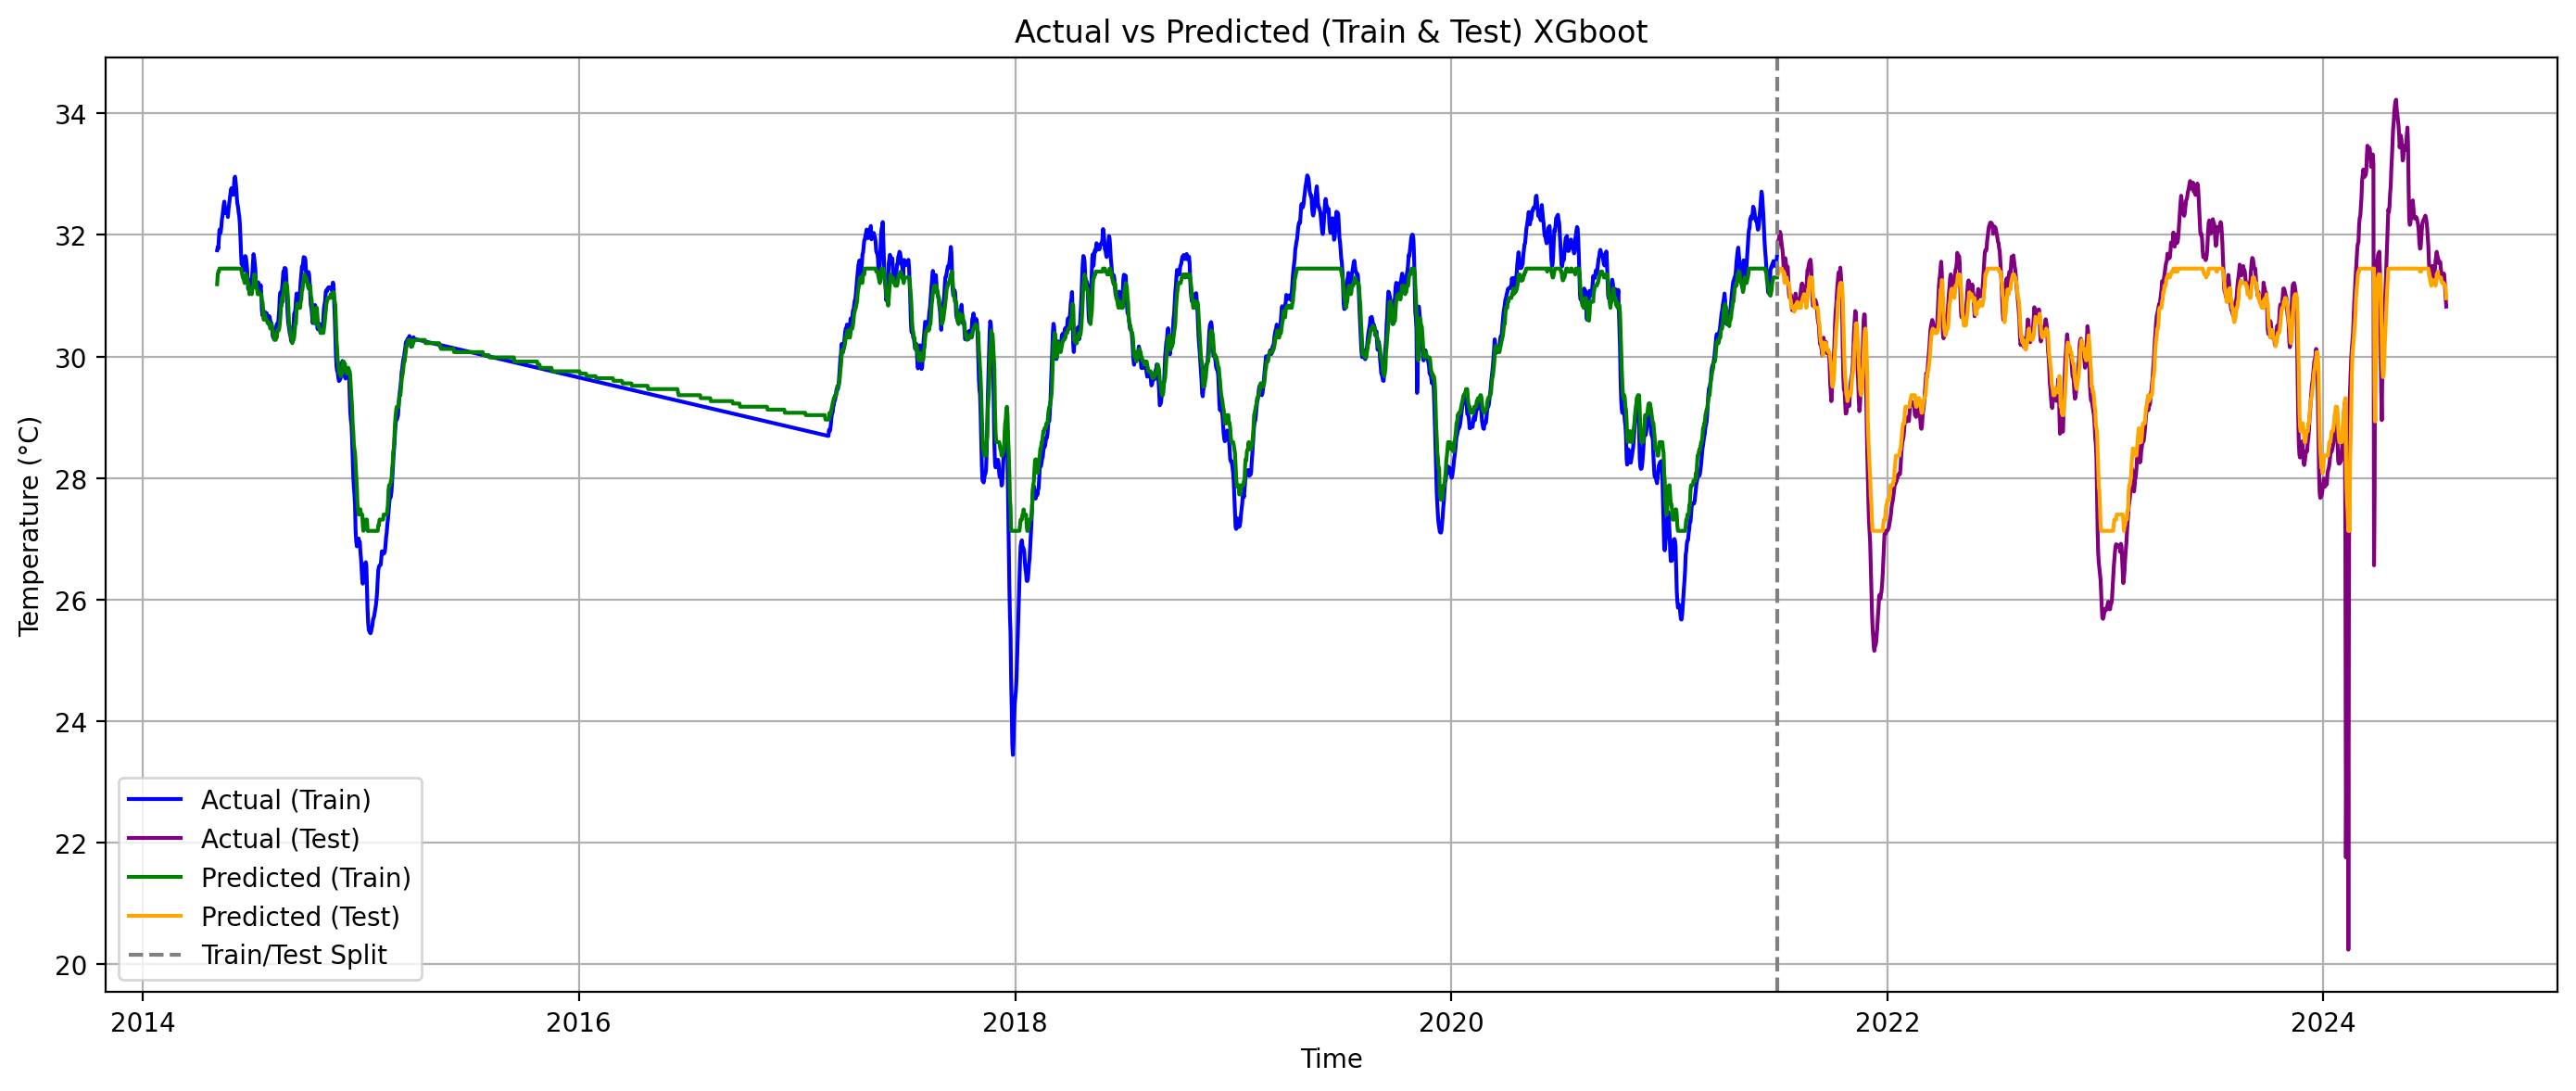

In [ ]:
plt.figure(figsize=(14, 6))
y_all = scaler.inverse_transform(y).ravel()
y_pred_train = best_xgb_regressor.predict(X_train1)
y_pred_train_inv = scaler.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()

# ค่าทำนายช่วงเทส
y_pred_test = best_xgb_regressor.predict(X_test1)
y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

# สร้างค่าทำนายรวม
y_pred_combined = np.full_like(y_all, np.nan)
y_pred_combined[:split_at] = y_pred_train_inv
y_pred_combined[split_at:] = y_pred_test_inv


plt.plot(y.index[:split_at], y_all[:split_at], color='blue', label='Actual (Train)')
plt.plot(y.index[split_at:], y_all[split_at:], color='purple', label='Actual (Test)')
plt.plot(y.index[:split_at], y_pred_combined[:split_at], color='green', label='Predicted (Train)')
plt.plot(y.index[split_at:], y_pred_combined[split_at:], color='orange', label='Predicted (Test)')
plt.axvline(x=y.index[split_at], color='gray', linestyle='--', label='Train/Test Split')
plt.title("Actual vs Predicted (Train & Test) XGboot")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## **test**

In [ ]:
# 1. ย้อนการสเกลของค่าที่ทำนายและค่าจริง
y_pred_scaled = best_xgb_regressor.predict(X_test1)
y_pred_original = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

# สมมติว่าคุณมีค่าจริง y_test1 ที่ถูกสเกลไว้ด้วย คุณควรย้อนการแปลงค่าจริงเหล่านั้น
y_test_original = scaler.inverse_transform(y_test1)

# 2. สร้าง DataFrame เพื่อความสะดวกในการเปรียบเทียบ
results_df = pd.DataFrame({
    "Predicted": y_pred_original.flatten(),
    "Actual": y_test_original.flatten()
})

# 3. พิมพ์ผลลัพธ์การเปรียบเทียบ
print("การเปรียบเทียบระหว่างค่าที่ทำนายและค่าจริง:")
print(results_df)

การเปรียบเทียบระหว่างค่าที่ทำนายและค่าจริง:
      Predicted     Actual
0     31.345036  31.794583
1     31.438747  31.908611
2     31.527328  31.927465
3     31.527328  31.984792
4     31.527328  32.051875
...         ...        ...
1116  31.164629  31.365139
1117  31.164629  31.287986
1118  31.164629  31.137361
1119  31.075151  30.967847
1120  30.925034  30.821606

[1121 rows x 2 columns]


## no.2

In [ ]:
 # ช่วงที่ 2
X_train2, X_test2 = X[9:split_at+9], np.concatenate((X[:9], X[split_at+9:]), axis=0)
y_train2, y_test2 = y[9:split_at+9], np.concatenate((y[:9], y[split_at+9:]), axis=0)

In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train2, y_train2, X_test2, y_test2)

[I 2025-05-06 19:42:06,071] A new study created in memory with name: no-name-1bf845ad-eaec-4ad5-bef5-0685e2277970
<ipython-input-54-065764a7206d>:43: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
<ipython-input-54-065764a7206d>:47: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
<ipython-input-54-065764a7206d>:48: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.s

Best hyperparameters:  {'learning_rate': 0.04994418655340134, 'max_depth': 5, 'n_estimators': 62, 'min_child_weight': 10, 'subsample': 0.5015520111510056, 'colsample_bytree': 0.5294842988894918, 'gamma': 0.5973405062288357, 'alpha': 0.005975543894351741, 'lambda': 0.00030336677179156437}
Test set performance:

R2: 0.8111090665416231
MAE: 0.03657153319842354
RMSE: 0.057135072033186185
MSE: 0.003264416456237374


ความสำคัญของตัวแปร:
       Feature  Importance
3  temp_lag_4    0.341385
2  temp_lag_3    0.232605
1  temp_lag_2    0.229593
0  temp_lag_1    0.196416
4  temp_lag_5    0.000000
5  temp_lag_6    0.000000
6  temp_lag_7    0.000000


array([0.7804991 , 0.7989657 , 0.7989657 , ..., 0.77897066, 0.7754012 ,
       0.7669888 ], dtype=float32)

## no.3

In [ ]:
# ช่วงที่ 3
X_train3, X_test3 = X[99:split_at+99], np.concatenate((X[:99], X[split_at+99:]), axis=0)
y_train3, y_test3 = y[99:split_at+99], np.concatenate((y[:99], y[split_at+99:]), axis=0)

In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train3, y_train3, X_test3, y_test3)

[I 2024-10-14 13:52:51,664] A new study created in memory with name: no-name-bf9e0b30-404a-41b1-86ba-0719c6c49bd7
<ipython-input-49-ddc53c32ee17>:48: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
<ipython-input-49-ddc53c32ee17>:52: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
<ipython-input-49-ddc53c32ee17>:53: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.s

Best hyperparameters:  {'learning_rate': 0.04999360024358302, 'max_depth': 6, 'n_estimators': 107, 'min_child_weight': 5, 'subsample': 0.5529301706462234, 'colsample_bytree': 0.49954475376204455, 'gamma': 0.5393617361671107, 'alpha': 2.923613893351457e-05, 'lambda': 6.08708818105111e-05}
Test set performance:


R2: 0.8128466897706421
MAE: 0.03726007538475848
RMSE: 0.057965025802818974
MSE: 0.0033599442163214695



ความสำคัญของตัวแปร:
       Feature  Importance
1  temp_lag_2    0.267782
4  temp_lag_5    0.238853
3  temp_lag_4    0.201811
0  temp_lag_1    0.176768
2  temp_lag_3    0.114785
5  temp_lag_6    0.000000
6  temp_lag_7    0.000000


# **EC**

In [ ]:
X = df[['EC_lag_1','EC_lag_2','EC_lag_3','EC_lag_4','EC_lag_5','EC_lag_6','EC_lag_7']]
y = df["Conductivity\n(uS/cm)"]

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y = pd.DataFrame(y_scaled, columns=[y.name], index=y.index)

In [ ]:
X

,EC_lag_1,EC_lag_2,EC_lag_3,EC_lag_4,EC_lag_5,EC_lag_6,EC_lag_7
date_time,,,,,,,
2014-05-05,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-06,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-07,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-08,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-09,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
...,...,...,...,...,...,...,...
2024-07-21,0.049742,0.050889,0.051868,0.053354,0.053240,0.052858,0.054915
2024-07-22,0.047915,0.049742,0.050889,0.051868,0.053354,0.053240,0.052858
2024-07-23,0.046390,0.047915,0.049742,0.050889,0.051868,0.053354,0.053240


In [ ]:
split_at = int(len(X) * 0.7)

## no.1

In [ ]:
# ช่วงที่ 1
X_train1, X_test1 = X[:split_at], X[split_at:]
y_train1, y_test1 = y[:split_at], y[split_at:]

In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=200)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor,X_train1, y_train1, X_test1, y_test1)

[I 2025-05-06 19:44:24,671] A new study created in memory with name: no-name-069288ee-a9ae-4162-a2e0-a084bccc9af8
<ipython-input-54-065764a7206d>:43: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
<ipython-input-54-065764a7206d>:47: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
<ipython-input-54-065764a7206d>:48: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.s

Best hyperparameters:  {'learning_rate': 0.049994182755930226, 'max_depth': 4, 'n_estimators': 117, 'min_child_weight': 10, 'subsample': 0.4511583327964665, 'colsample_bytree': 0.576678157774588, 'gamma': 0.6714000547371124, 'alpha': 0.001659377708856885, 'lambda': 3.627105235232351e-05}
Test set performance:

R2: 0.7825626730918884
MAE: 0.017885103821754456
RMSE: 0.027953717383197674
MSE: 0.0007814103155396879


ความสำคัญของตัวแปร:
     Feature  Importance
1  EC_lag_2    0.359580
0  EC_lag_1    0.218959
2  EC_lag_3    0.187556
3  EC_lag_4    0.140940
4  EC_lag_5    0.092965
5  EC_lag_6    0.000000
6  EC_lag_7    0.000000


array([0.40818506, 0.40818506, 0.37578762, ..., 0.0570071 , 0.0570071 ,
       0.0570071 ], dtype=float32)

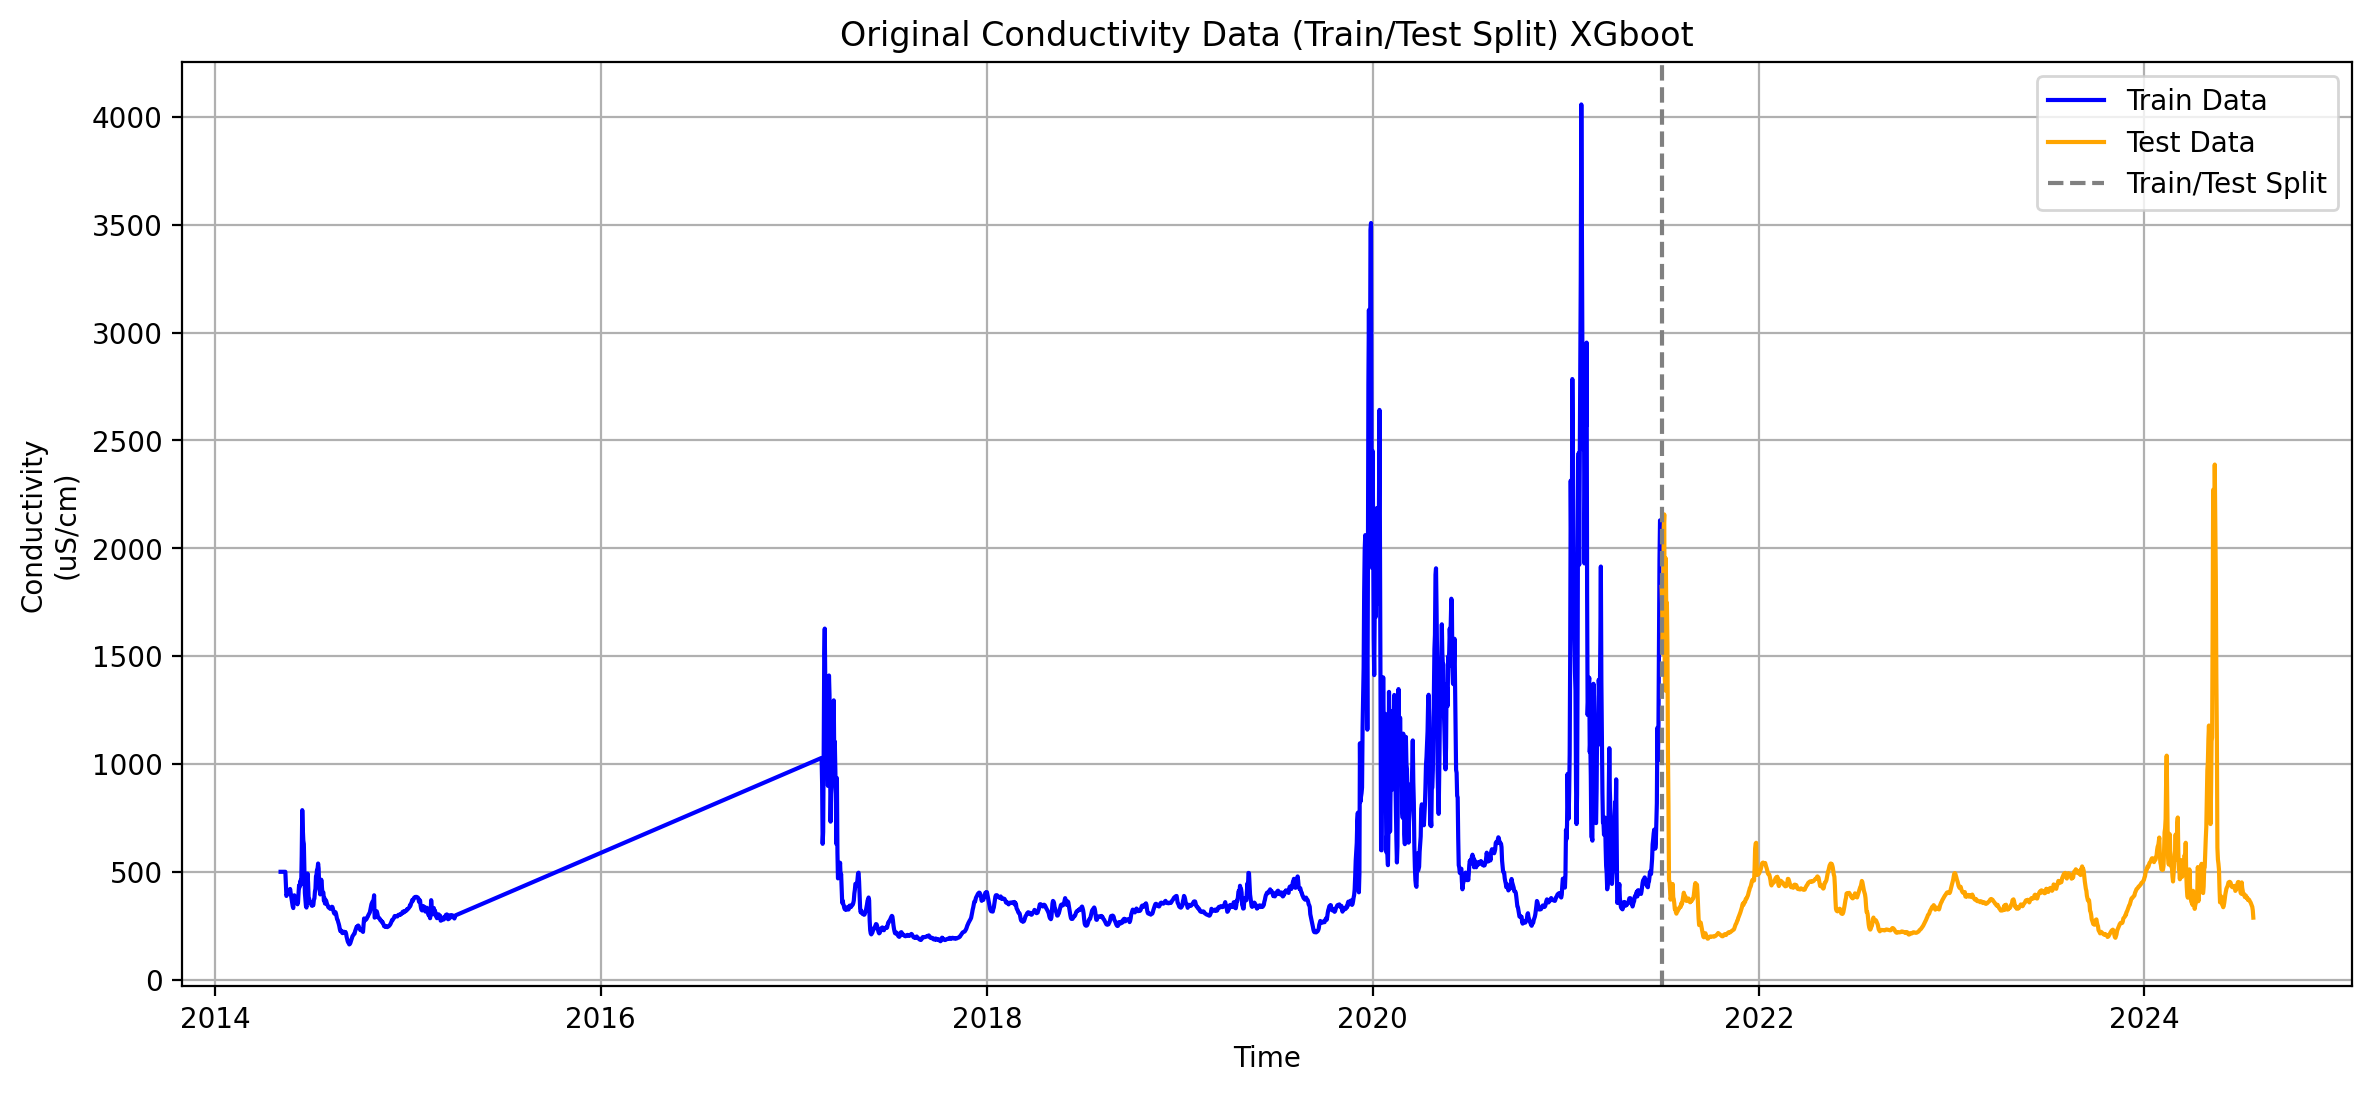

In [ ]:
plt.figure(figsize=(14, 6))
y_inv = scaler.inverse_transform(y) #กลับค่า y เป็นสเกลจริง

y_train_inv = y_inv[:split_at]
y_test_inv = y_inv[split_at:]

plt.plot(y.index[:split_at], y_train_inv, label="Train Data", color='blue')
plt.plot(y.index[split_at:], y_test_inv, label="Test Data", color='orange')
plt.axvline(x=y.index[split_at], color='gray', linestyle='--', label='Train/Test Split') #เส้นเเบ่ง
plt.title("Original Conductivity Data (Train/Test Split) XGboot")
plt.xlabel("Time")
plt.ylabel("Conductivity\n(uS/cm)")
plt.legend()
plt.grid(True)
plt.show()


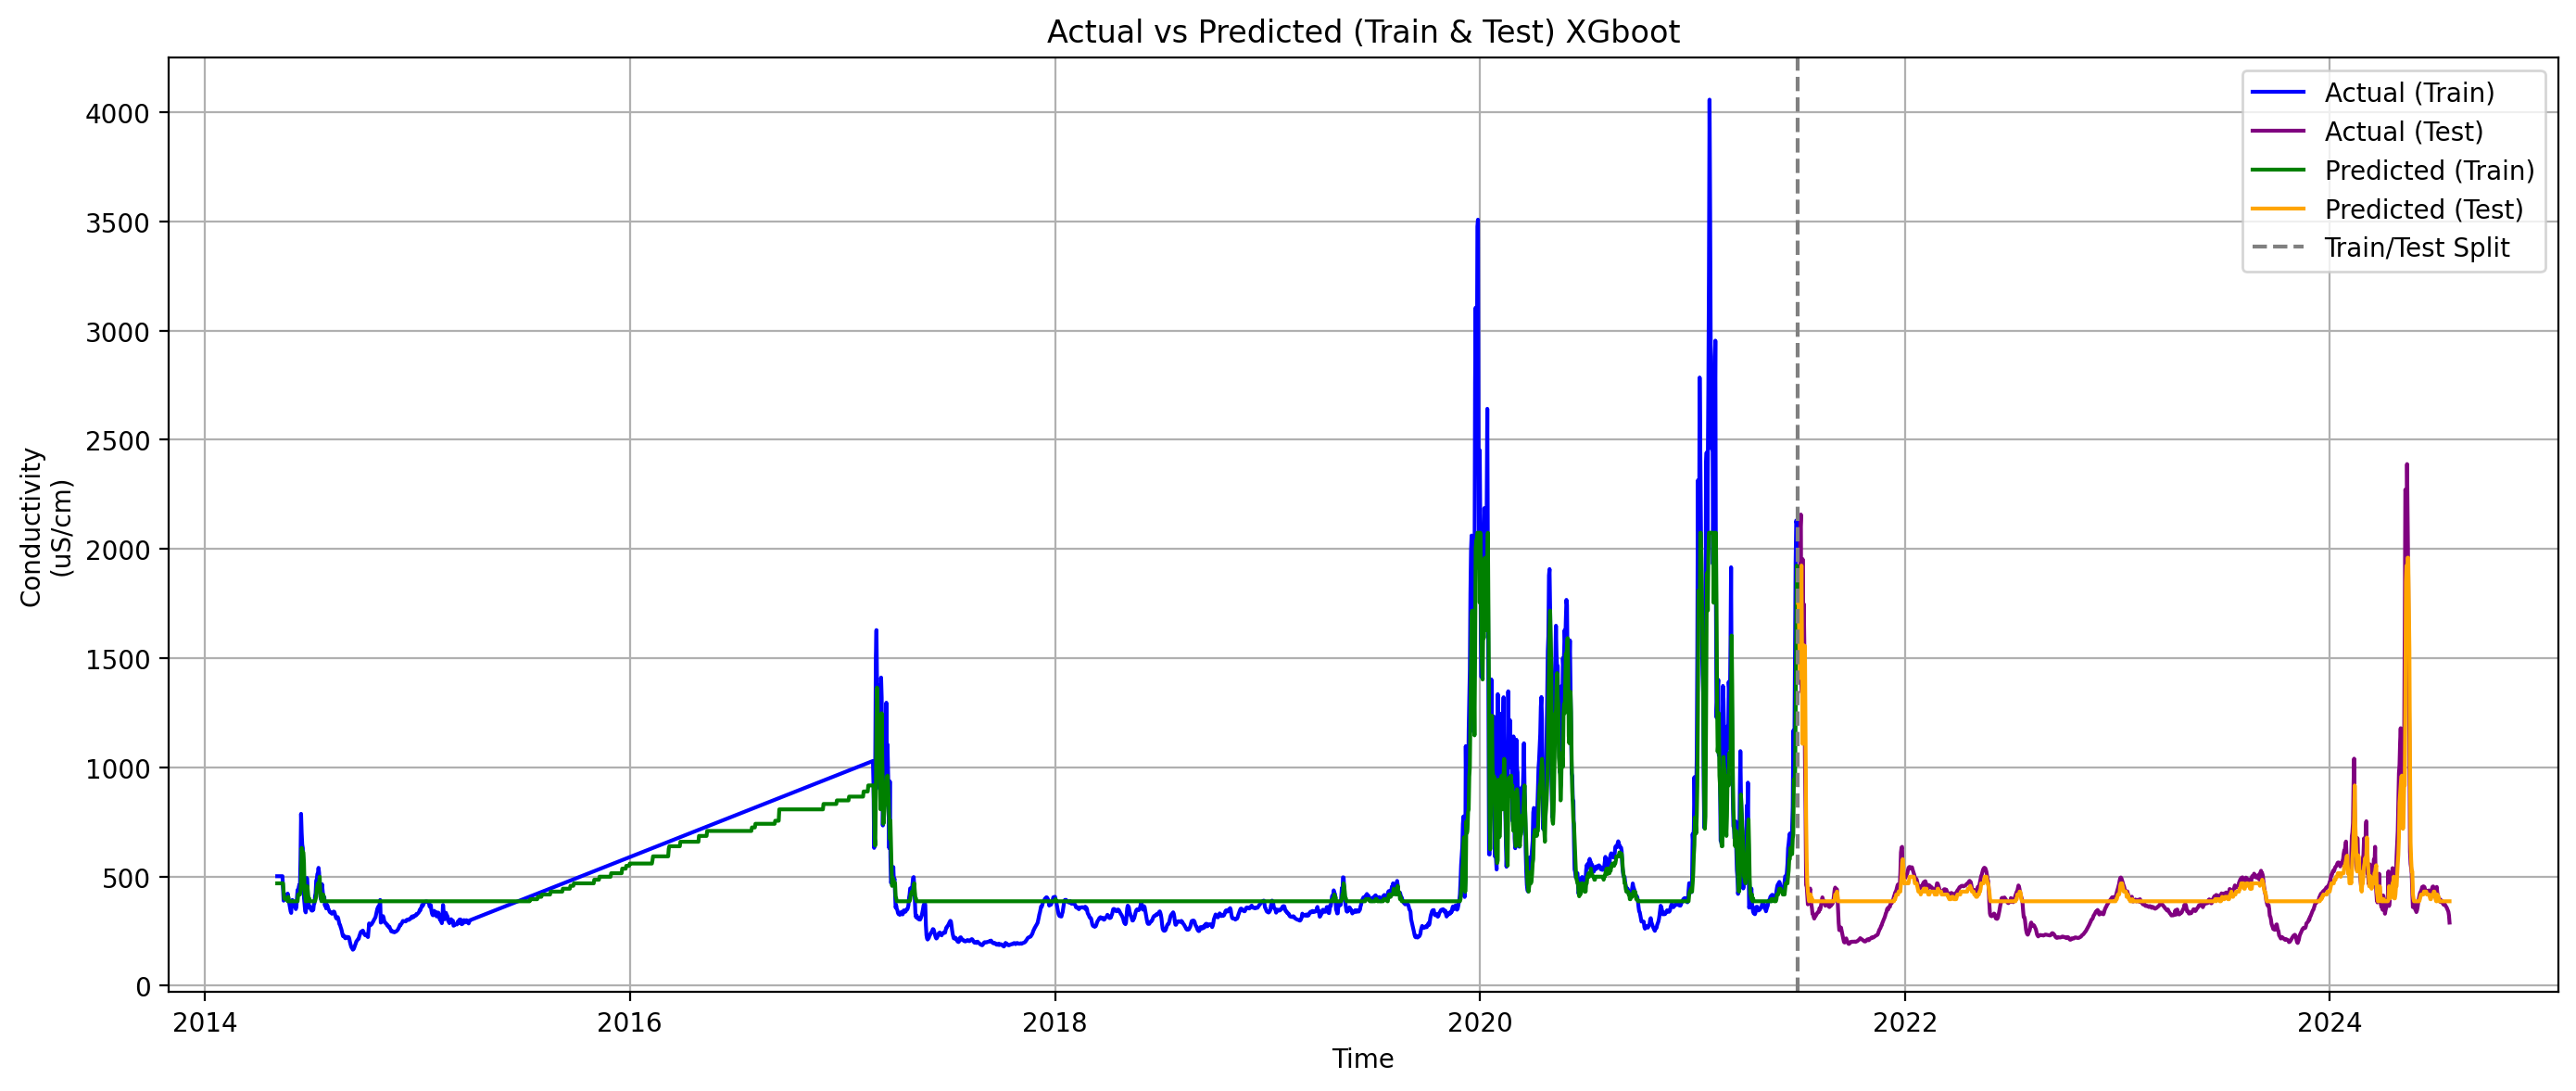

In [ ]:
plt.figure(figsize=(14, 6))
y_all = scaler.inverse_transform(y).ravel()
y_pred_train = best_xgb_regressor.predict(X_train1)
y_pred_train_inv = scaler.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()

# ค่าทำนายช่วงเทส
y_pred_test = best_xgb_regressor.predict(X_test1)
y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

# สร้างค่าทำนายรวม
y_pred_combined = np.full_like(y_all, np.nan)
y_pred_combined[:split_at] = y_pred_train_inv
y_pred_combined[split_at:] = y_pred_test_inv


plt.plot(y.index[:split_at], y_all[:split_at], color='blue', label='Actual (Train)')
plt.plot(y.index[split_at:], y_all[split_at:], color='purple', label='Actual (Test)')
plt.plot(y.index[:split_at], y_pred_combined[:split_at], color='green', label='Predicted (Train)')
plt.plot(y.index[split_at:], y_pred_combined[split_at:], color='orange', label='Predicted (Test)')
plt.axvline(x=y.index[split_at], color='gray', linestyle='--', label='Train/Test Split')
plt.title("Actual vs Predicted (Train & Test) XGboot")
plt.xlabel("Time")
plt.ylabel("Conductivity\n(uS/cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## no.2

In [ ]:
 # ช่วงที่ 2
X_train2, X_test2 = X[9:split_at+9], np.concatenate((X[:9], X[split_at+9:]), axis=0)
y_train2, y_test2 = y[9:split_at+9], np.concatenate((y[:9], y[split_at+9:]), axis=0)

In [ ]:
X

,EC_lag_1,EC_lag_2,EC_lag_3,EC_lag_4,EC_lag_5,EC_lag_6,EC_lag_7
date_time,,,,,,,
2014-05-05,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-06,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-07,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-08,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
2014-05-09,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492,0.086492
...,...,...,...,...,...,...,...
2024-07-21,0.049742,0.050889,0.051868,0.053354,0.053240,0.052858,0.054915
2024-07-22,0.047915,0.049742,0.050889,0.051868,0.053354,0.053240,0.052858
2024-07-23,0.046390,0.047915,0.049742,0.050889,0.051868,0.053354,0.053240


In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train2,y_train2, X_test2, y_test2)

[I 2024-10-14 13:54:07,513] A new study created in memory with name: no-name-820786e8-35ce-4812-82c6-9da613bae8bf
<ipython-input-49-ddc53c32ee17>:48: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
<ipython-input-49-ddc53c32ee17>:52: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
<ipython-input-49-ddc53c32ee17>:53: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.s

Best hyperparameters:  {'learning_rate': 0.04999636832602349, 'max_depth': 5, 'n_estimators': 113, 'min_child_weight': 9, 'subsample': 0.5816073229568337, 'colsample_bytree': 0.5774183438130841, 'gamma': 0.5313285143272583, 'alpha': 1.2154738075962065e-05, 'lambda': 8.634684252928438e-05}
Test set performance:


R2: 0.7694116690388977
MAE: 0.01583062566014072
RMSE: 0.024552006466364008
MSE: 0.0006028010215243801



ความสำคัญของตัวแปร:
     Feature  Importance
1  EC_lag_2    0.333571
0  EC_lag_1    0.211177
4  EC_lag_5    0.144777
5  EC_lag_6    0.133512
2  EC_lag_3    0.098179
3  EC_lag_4    0.078785
6  EC_lag_7    0.000000


## no.3

In [ ]:
# ช่วงที่ 3
X_train3, X_test3 = X[99:split_at+99], np.concatenate((X[:99], X[split_at+99:]), axis=0)
y_train3, y_test3 = y[99:split_at+99], np.concatenate((y[:99], y[split_at+99:]), axis=0)

In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train3, y_train3, X_test3, y_test3)

[I 2024-10-14 13:54:24,633] A new study created in memory with name: no-name-2bc1307b-f5de-4673-b14a-de3b6880ee47
<ipython-input-49-ddc53c32ee17>:48: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
<ipython-input-49-ddc53c32ee17>:52: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
<ipython-input-49-ddc53c32ee17>:53: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.s

Best hyperparameters:  {'learning_rate': 0.04997829221641542, 'max_depth': 5, 'n_estimators': 149, 'min_child_weight': 8, 'subsample': 0.41093687421843533, 'colsample_bytree': 0.5007401463259497, 'gamma': 0.671706637907407, 'alpha': 0.00313525819861133, 'lambda': 1.658524608722347e-05}
Test set performance:


R2: 0.7154757574413604
MAE: 0.016877870769380122
RMSE: 0.02542346950922168
MSE: 0.0006463528018863244



ความสำคัญของตัวแปร:
     Feature  Importance
6  EC_lag_7    0.216410
1  EC_lag_2    0.205148
4  EC_lag_5    0.193201
0  EC_lag_1    0.132178
3  EC_lag_4    0.093142
2  EC_lag_3    0.083956
5  EC_lag_6    0.075965


# **DO**

In [ ]:
X = df[['DO_lag_1','DO_lag_2','DO_lag_3','DO_lag_4','DO_lag_5','DO_lag_6','DO_lag_7']]
y = df["DO\n(mg/L)"]

In [ ]:
X

,DO_lag_1,DO_lag_2,DO_lag_3,DO_lag_4,DO_lag_5,DO_lag_6,DO_lag_7
date_time,,,,,,,
2014-05-05,4.448542,4.928164,5.571919,6.163383,6.754846,7.346309,7.757047
2014-05-06,4.301528,4.448542,4.928164,5.571919,6.163383,6.754846,7.346309
2014-05-07,4.414688,4.301528,4.448542,4.928164,5.571919,6.163383,6.754846
2014-05-08,4.339514,4.414688,4.301528,4.448542,4.928164,5.571919,6.163383
2014-05-09,4.385625,4.339514,4.414688,4.301528,4.448542,4.928164,5.571919
...,...,...,...,...,...,...,...
2024-07-21,2.276389,2.389653,2.618611,2.654931,2.706875,2.588125,2.585417
2024-07-22,2.146181,2.276389,2.389653,2.618611,2.654931,2.706875,2.588125
2024-07-23,2.114375,2.146181,2.276389,2.389653,2.618611,2.654931,2.706875


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
y = pd.DataFrame(y_scaled, columns=[y.name], index=y.index)

In [ ]:
split_at = int(len(X) * 0.7)

## no.1

In [ ]:
# ช่วงที่ 1
X_train1, X_test1 = X[:split_at], X[split_at:]
y_train1, y_test1 = y[:split_at], y[split_at:]

In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train1, y_train1, X_test1, y_test1)

[I 2025-05-06 19:51:45,523] A new study created in memory with name: no-name-a7caa0a3-0740-485b-b087-ea02c43efb34
<ipython-input-54-065764a7206d>:43: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
<ipython-input-54-065764a7206d>:47: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
<ipython-input-54-065764a7206d>:48: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.s

Best hyperparameters:  {'learning_rate': 0.04985438649953284, 'max_depth': 3, 'n_estimators': 82, 'min_child_weight': 10, 'subsample': 0.5914121553715842, 'colsample_bytree': 0.5878100020059629, 'gamma': 0.5763256214123537, 'alpha': 1.003549638278525e-05, 'lambda': 0.00015205614924215915}
Test set performance:

R2: 0.8223520517349243
MAE: 0.05193526670336723
RMSE: 0.08107332222226192
MSE: 0.006572883576154709


ความสำคัญของตัวแปร:
     Feature  Importance
1  DO_lag_2    0.451135
0  DO_lag_1    0.286033
2  DO_lag_3    0.262832
3  DO_lag_4    0.000000
4  DO_lag_5    0.000000
5  DO_lag_6    0.000000
6  DO_lag_7    0.000000


array([0.39278522, 0.39278522, 0.39645824, ..., 0.2744957 , 0.26819697,
       0.30616164], dtype=float32)

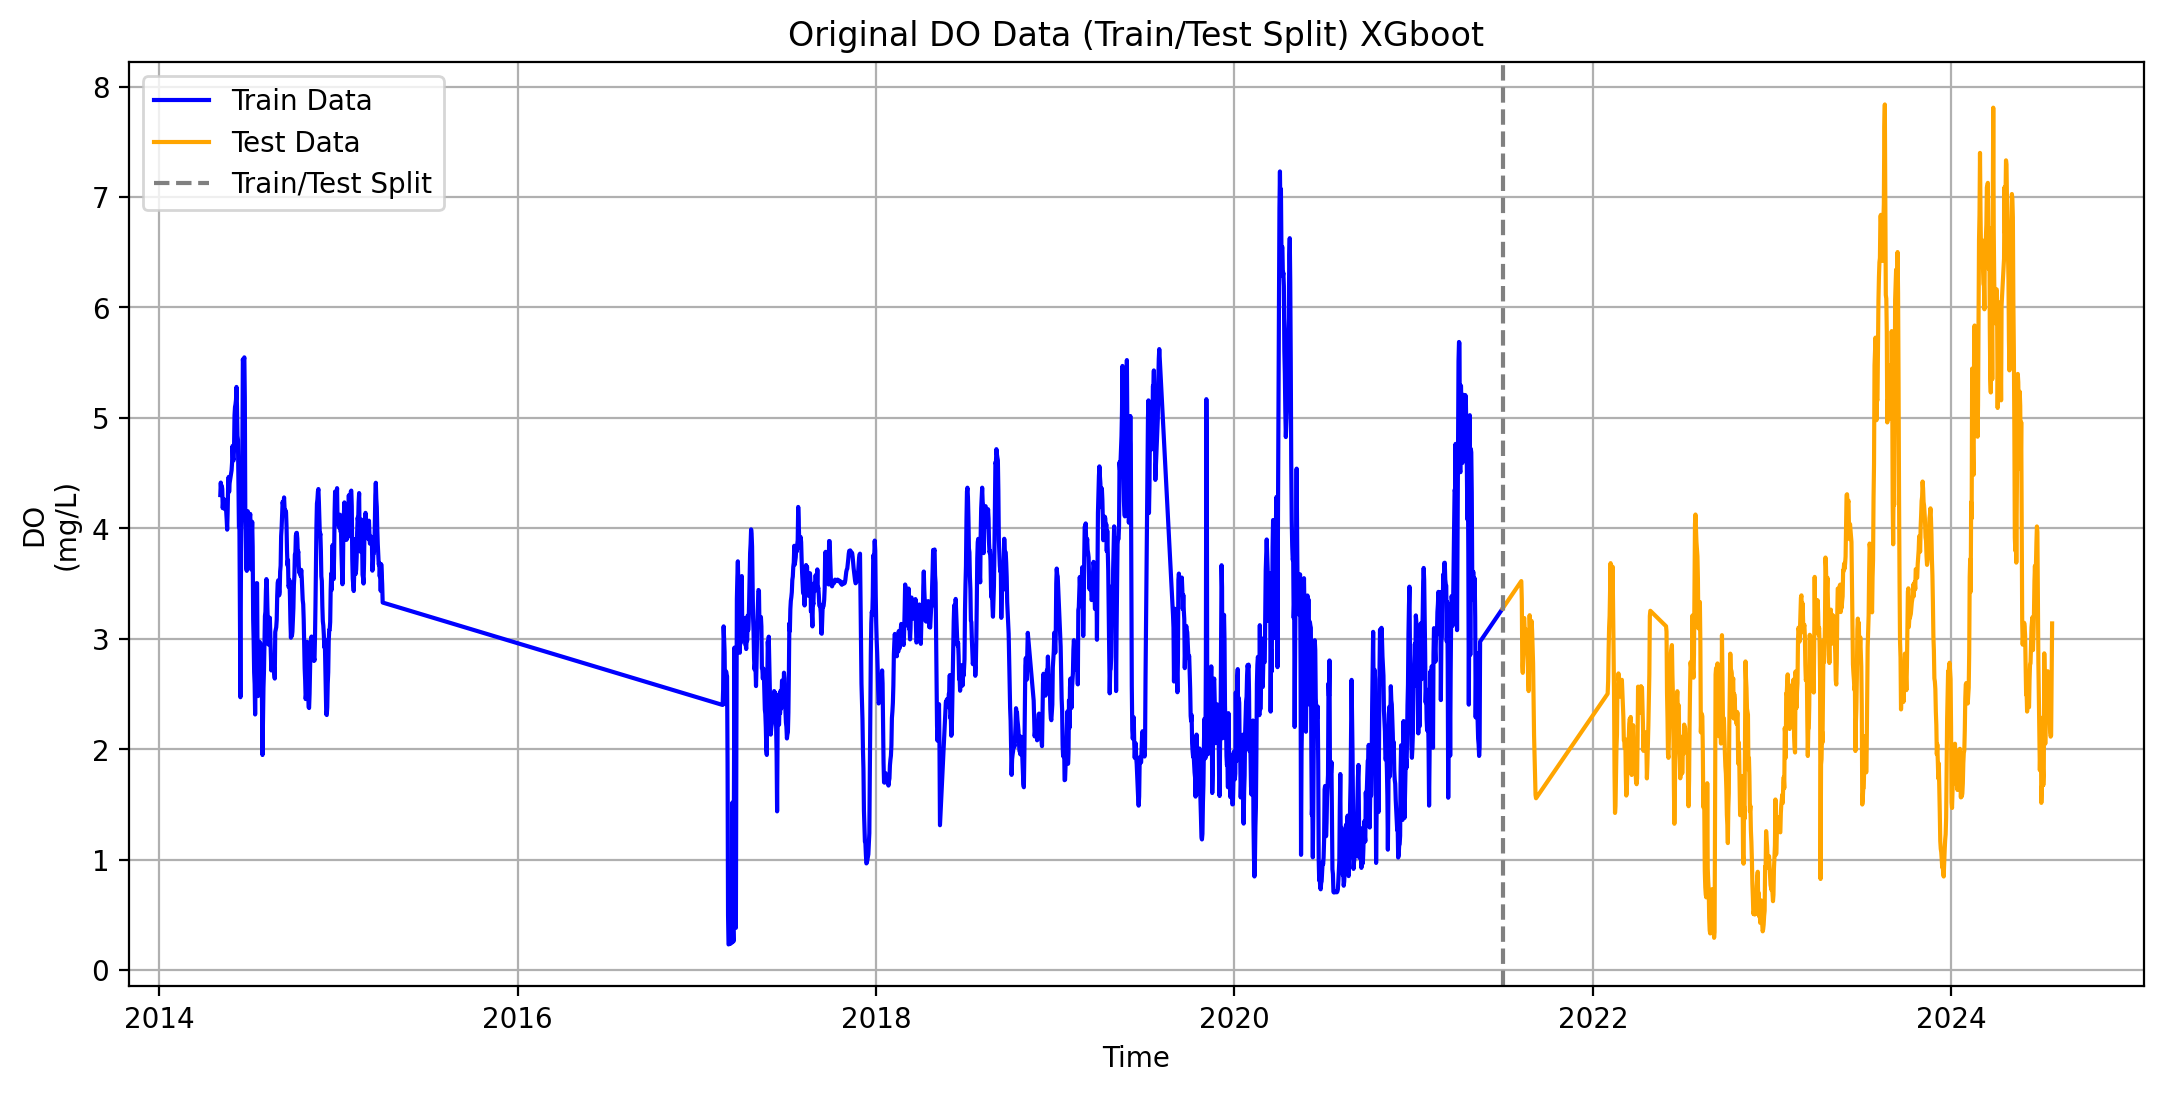

In [ ]:
plt.figure(figsize=(13, 6))
y_inv = scaler.inverse_transform(y) #กลับค่า y เป็นสเกลจริง

y_train_inv = y_inv[:split_at]
y_test_inv = y_inv[split_at:]

plt.plot(y.index[:split_at], y_train_inv, label="Train Data", color='blue')
plt.plot(y.index[split_at:], y_test_inv, label="Test Data", color='orange')
plt.axvline(x=y.index[split_at], color='gray', linestyle='--', label='Train/Test Split') #เส้นเเบ่ง
plt.title("Original DO Data (Train/Test Split) XGboot")
plt.xlabel("Time")
plt.ylabel("DO\n(mg/L)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
plt.figure(figsize=(13, 6))
y_all = scaler.inverse_transform(y).ravel()
y_pred_train = best_xgb_regressor.predict(X_train1)
y_pred_train_inv = scaler.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()

# ค่าทำนายช่วงเทส
y_pred_test = best_xgb_regressor.predict(X_test1)
y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

# สร้างค่าทำนายรวม
y_pred_combined = np.full_like(y_all, np.nan)
y_pred_combined[:split_at] = y_pred_train_inv
y_pred_combined[split_at:] = y_pred_test_inv


plt.plot(y.index[:split_at], y_all[:split_at], color='blue', label='Actual (Train)')
plt.plot(y.index[split_at:], y_all[split_at:], color='purple', label='Actual (Test)')
plt.plot(y.index[:split_at], y_pred_combined[:split_at], color='green', label='Predicted (Train)')
plt.plot(y.index[split_at:], y_pred_combined[split_at:], color='orange', label='Predicted (Test)')
plt.axvline(x=y.index[split_at], color='gray', linestyle='--', label='Train/Test Split')
plt.title("Actual vs Predicted (Train & Test) XGboot")
plt.xlabel("Time")
plt.ylabel("DO\n(mg/L)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

## no.2

In [ ]:
 # ช่วงที่ 2
X_train2, X_test2 = X[9:split_at+9], np.concatenate((X[:9], X[split_at+9:]), axis=0)
y_train2, y_test2 = y[9:split_at+9], np.concatenate((y[:9], y[split_at+9:]), axis=0)

In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train2, y_train2, X_test2, y_test2)

[I 2024-10-14 13:55:17,935] A new study created in memory with name: no-name-235eac47-b49e-4d38-a701-61c1eea8a6b5
<ipython-input-49-ddc53c32ee17>:48: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
<ipython-input-49-ddc53c32ee17>:52: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
<ipython-input-49-ddc53c32ee17>:53: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.s

Best hyperparameters:  {'learning_rate': 0.04987355192532724, 'max_depth': 3, 'n_estimators': 89, 'min_child_weight': 10, 'subsample': 0.48791082855920187, 'colsample_bytree': 0.5870700773611927, 'gamma': 0.8501400259641726, 'alpha': 0.0036093004935760413, 'lambda': 0.004041043953971401}
Test set performance:


R2: 0.7544884764532936
MAE: 0.06075405350645252
RMSE: 0.0956337664486733
MSE: 0.009145817285159391



ความสำคัญของตัวแปร:
     Feature  Importance
1  DO_lag_2    0.390709
0  DO_lag_1    0.286129
2  DO_lag_3    0.188077
3  DO_lag_4    0.135085
4  DO_lag_5    0.000000
5  DO_lag_6    0.000000
6  DO_lag_7    0.000000


## no.3

In [ ]:
# ช่วงที่ 3
X_train3, X_test3 = X[99:split_at+99], np.concatenate((X[:99], X[split_at+99:]), axis=0)
y_train3, y_test3 = y[99:split_at+99], np.concatenate((y[:99], y[split_at+99:]), axis=0)

In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train3, y_train3, X_test3, y_test3)

[I 2024-10-14 13:55:43,399] A new study created in memory with name: no-name-7d037154-b3e4-49b6-8ba8-855ab5dea495
<ipython-input-49-ddc53c32ee17>:48: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),  # ค่า learning rate
<ipython-input-49-ddc53c32ee17>:52: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.4, 0.6),  #  subsample
<ipython-input-49-ddc53c32ee17>:53: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.s

Best hyperparameters:  {'learning_rate': 0.0499517038300884, 'max_depth': 6, 'n_estimators': 102, 'min_child_weight': 6, 'subsample': 0.4577455279636107, 'colsample_bytree': 0.49635702013811356, 'gamma': 0.5028333171745348, 'alpha': 4.605185984638141e-05, 'lambda': 1.428060181855961e-05}
Test set performance:


R2: 0.8157989994156978
MAE: 0.05592384984036292
RMSE: 0.08411840501162646
MSE: 0.0070759060617000226



ความสำคัญของตัวแปร:
     Feature  Importance
1  DO_lag_2    0.279619
3  DO_lag_4    0.221625
4  DO_lag_5    0.190211
0  DO_lag_1    0.173302
2  DO_lag_3    0.135244
5  DO_lag_6    0.000000
6  DO_lag_7    0.000000


# **pH**

In [ ]:
df['pH'][3715:3735]

,pH
date_time,
2024-07-06,6.432639
2024-07-07,5.970347
2024-07-08,6.217419
2024-07-09,4.419900
2024-07-10,2.082611
2024-07-11,2.773056
2024-07-12,3.080000
2024-07-13,3.080000
2024-07-14,3.080000


In [ ]:
zero_counts = (df == 3.080000).sum()
print(zero_counts)

Temperature\n(֯C)         0
Conductivity\n(uS/cm)     0
DO\n(mg/L)                0
pH                       14
day                       0
month                     0
year                      0
season                    0
day_month_interaction     0
temp_lag_1                0
temp_lag_2                0
temp_lag_3                0
temp_lag_4                0
temp_lag_5                0
temp_lag_6                0
temp_lag_7                0
EC_lag_1                  0
EC_lag_2                  0
EC_lag_3                  0
EC_lag_4                  0
EC_lag_5                  0
EC_lag_6                  0
EC_lag_7                  0
DO_lag_1                  0
DO_lag_2                  0
DO_lag_3                  0
DO_lag_4                  0
DO_lag_5                  0
DO_lag_6                  0
DO_lag_7                  0
pH_lag_1                 13
pH_lag_2                 12
pH_lag_3                 11
pH_lag_4                 10
pH_lag_5                  9
pH_lag_6            

In [ ]:
 df= df.replace(3.080000, np.nan)

In [ ]:
zero_counts = (df == 3.080000).sum()
print(zero_counts)

Temperature\n(֯C)        0
Conductivity\n(uS/cm)    0
DO\n(mg/L)               0
pH                       0
day                      0
month                    0
year                     0
season                   0
day_month_interaction    0
temp_lag_1               0
temp_lag_2               0
temp_lag_3               0
temp_lag_4               0
temp_lag_5               0
temp_lag_6               0
temp_lag_7               0
EC_lag_1                 0
EC_lag_2                 0
EC_lag_3                 0
EC_lag_4                 0
EC_lag_5                 0
EC_lag_6                 0
EC_lag_7                 0
DO_lag_1                 0
DO_lag_2                 0
DO_lag_3                 0
DO_lag_4                 0
DO_lag_5                 0
DO_lag_6                 0
DO_lag_7                 0
pH_lag_1                 0
pH_lag_2                 0
pH_lag_3                 0
pH_lag_4                 0
pH_lag_5                 0
pH_lag_6                 0
pH_lag_7                 0
d

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Temperature\n(֯C),0
Conductivity\n(uS/cm),0
DO\n(mg/L),0
pH,0
day,0
month,0
year,0
season,0
day_month_interaction,0
temp_lag_1,0


In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,day,month,year,season,day_month_interaction,temp_lag_1,...,DO_lag_5,DO_lag_6,DO_lag_7,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
date_time,,,,,,,,,,,,,,,,,,,,,
2014-05-05,31.747917,501.199898,4.301528,7.620000,5.0,5.0,2014.0,2.0,25.0,31.693750,...,6.754846,7.346309,7.757047,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638,9.276510
2014-05-06,31.799965,501.199898,4.414688,7.693785,6.0,5.0,2014.0,2.0,30.0,31.747917,...,6.163383,6.754846,7.346309,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638
2014-05-07,31.775764,501.199898,4.339514,7.719306,7.0,5.0,2014.0,2.0,35.0,31.799965,...,5.571919,6.163383,6.754846,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181
2014-05-08,31.948542,501.199898,4.385625,7.705069,8.0,5.0,2014.0,2.0,40.0,31.775764,...,4.928164,5.571919,6.163383,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725
2014-05-09,32.087292,501.199898,4.356528,7.682674,9.0,5.0,2014.0,2.0,45.0,31.948542,...,4.448542,4.928164,5.571919,7.705069,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-21,31.365139,351.027778,2.146181,3.080000,21.0,7.0,2024.0,3.0,147.0,31.311667,...,2.706875,2.588125,2.585417,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000
2024-07-22,31.287986,345.090278,2.114375,3.080000,22.0,7.0,2024.0,3.0,154.0,31.365139,...,2.654931,2.706875,2.588125,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000
2024-07-23,31.137361,338.798611,2.126111,3.080000,23.0,7.0,2024.0,3.0,161.0,31.287986,...,2.618611,2.654931,2.706875,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000


In [ ]:
df

,Temperature\n(֯C),Conductivity\n(uS/cm),DO\n(mg/L),pH,day,month,year,season,day_month_interaction,temp_lag_1,...,DO_lag_5,DO_lag_6,DO_lag_7,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
date_time,,,,,,,,,,,,,,,,,,,,,
2014-05-05,31.747917,501.199898,4.301528,7.620000,5.0,5.0,2014.0,2.0,25.0,31.693750,...,6.754846,7.346309,7.757047,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638,9.276510
2014-05-06,31.799965,501.199898,4.414688,7.693785,6.0,5.0,2014.0,2.0,30.0,31.747917,...,6.163383,6.754846,7.346309,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181,9.045638
2014-05-07,31.775764,501.199898,4.339514,7.719306,7.0,5.0,2014.0,2.0,35.0,31.799965,...,5.571919,6.163383,6.754846,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725,8.713181
2014-05-08,31.948542,501.199898,4.385625,7.705069,8.0,5.0,2014.0,2.0,40.0,31.775764,...,4.928164,5.571919,6.163383,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268,8.380725
2014-05-09,32.087292,501.199898,4.356528,7.682674,9.0,5.0,2014.0,2.0,45.0,31.948542,...,4.448542,4.928164,5.571919,7.705069,7.719306,7.693785,7.620000,7.597917,7.711670,8.048268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-21,31.365139,351.027778,2.146181,3.080000,21.0,7.0,2024.0,3.0,147.0,31.311667,...,2.706875,2.588125,2.585417,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000
2024-07-22,31.287986,345.090278,2.114375,3.080000,22.0,7.0,2024.0,3.0,154.0,31.365139,...,2.654931,2.706875,2.588125,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000
2024-07-23,31.137361,338.798611,2.126111,3.080000,23.0,7.0,2024.0,3.0,161.0,31.287986,...,2.618611,2.654931,2.706875,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000,3.080000


In [ ]:
df = df[df['pH'] >= 4]

In [ ]:
X = df[['pH_lag_1','pH_lag_2','pH_lag_3','pH_lag_4','pH_lag_5','pH_lag_6','pH_lag_7']]
y = df["pH"]

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
#X_scaled = pd.DataFrame(X_scaled, columns=columns_to_scale)
#X = pd.concat([X_scaled, X_not_scaled.reset_index(drop=True)], axis=1)

X = pd.DataFrame(X_scaled, columns=X.columns)
y = pd.DataFrame(y_scaled, columns=[y.name], index=y.index)

In [ ]:
X

,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7
0,0.764613,0.804453,0.922342,1.000000,1.000000,1.000000,1.000000
1,0.772347,0.764613,0.804453,0.887909,0.899207,0.908436,0.940215
2,0.798189,0.772347,0.764613,0.774421,0.798414,0.816872,0.854125
3,0.807127,0.798189,0.772347,0.736068,0.696365,0.725308,0.768035
4,0.802141,0.807127,0.798189,0.743514,0.661877,0.632603,0.681945
...,...,...,...,...,...,...,...
3714,0.425808,0.431962,0.474695,0.434871,0.390513,0.362349,0.366653
3715,0.407956,0.425808,0.431962,0.456974,0.391039,0.354756,0.340686
3716,0.356491,0.407956,0.425808,0.415836,0.410914,0.355234,0.333547
3717,0.194580,0.356491,0.407956,0.409912,0.373922,0.373289,0.333996


In [ ]:
y

,pH
date_time,
2014-05-05,0.831173
2014-05-06,0.850338
2014-05-07,0.856966
2014-05-08,0.853269
2014-05-09,0.847452
...,...
2024-07-05,0.560942
2024-07-06,0.522776
2024-07-07,0.402703


วิธีการเทรนโดยการเอาหลายโมเดลมาคุยกัน!!!!

In [ ]:
import optuna
from optuna.samplers import TPESampler
def regression_model(clf, X_train, y_train, X_test, y_test, show_feature_importance=True):
    # ฝึกโมเดล
    clf_model = clf.fit(X_train, y_train,
                        eval_set=[(X_test, y_test)],
                        early_stopping_rounds=10,
                        verbose=False)

    # ทำนายผลบนชุดข้อมูลฝึก
    y_hat_train = clf_model.predict(X_train)

    # ทำนายผลบนชุดข้อมูลทดสอบ
    y_hat_test = clf_model.predict(X_test)

    # คำนวณค่า MAE, RMSE, MSE สำหรับชุดข้อมูลทดสอบ
    mae = mean_absolute_error(y_test, y_hat_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_hat_test))
    mse = mean_squared_error(y_test, y_hat_test)
    train_r2 = r2_score(y_test,y_hat_test)

    print('Test set performance:')
    print('\n')
    print(f'R2: {train_r2}')
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')
    print(f'MSE: {mse}')
    print('\n')

    # ความสำคัญของตัวแปร
    # Corrected indentation: Changed 3 spaces to 4 spaces
    if show_feature_importance and hasattr(clf, 'named_estimators_'):
        for name, estimator in clf.named_estimators_.items():
            if hasattr(estimator, 'feature_importances_'):
                feature_importances = estimator.feature_importances_
                feature_df = pd.DataFrame({
                    "Feature": X_train.columns,
                    "Importance": feature_importances
                }).sort_values(by="Importance", ascending=False)
                print(f"\nFeature importance for {name}:\n", feature_df)
#Loss Function
def huber_approx_obj(preds, dtrain):
    d = preds - dtrain.get_label()
    h = 3
    scale = 1 + (d / h)**2
    grad = d / scale
    hess = 1 / scale
    return grad, hess

#objective สำหรับ Optuna
def objective(trial):
    param = {
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
        'alpha': trial.suggest_loguniform('alpha', 1e-5, 1e-1),  # L1 regularization
        'lambda': trial.suggest_loguniform('lambda', 1e-5, 1e-1),  # L2 regularization
        'random_state': 0
    }

    # สร้างโมเดล XGBoost ด้วย Custom Huber Loss
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        **param
    )
    model.fit(X_train1, y_train1,
              eval_set=[(X_test1, y_test1)],
              early_stopping_rounds=10,
              verbose=False)

    y_pred = model.predict(X_test1)
    mse = mean_squared_error(y_test1, y_pred)
    return mse

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import VotingRegressor
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=150)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=0,
    **study.best_params
)
best_xgb_regressor.fit(X_train1, y_train1)
model_lr = LinearRegression()
model_dt = DecisionTreeRegressor(random_state=0)

voting_regressor = VotingRegressor(estimators=[
    ('xgb', best_xgb_regressor),
    ('lr', model_lr),
    ('dt', model_dt)
])

# ประเมินผลโมเดล
regression_model(voting_regressor, X_train1, y_train1, X_test1, y_test1)

[I 2024-10-13 16:43:45,135] A new study created in memory with name: no-name-1ef664d7-4aa7-4cbe-a7ea-cd509f25aa65
<ipython-input-101-86d6c82af00f>:50: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
<ipython-input-101-86d6c82af00f>:54: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
<ipython-input-101-86d6c82af00f>:55: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree'

Best hyperparameters:  {'learning_rate': 0.19988309678223523, 'max_depth': 5, 'n_estimators': 715, 'min_child_weight': 7, 'subsample': 0.8244423452904843, 'colsample_bytree': 0.9588272827368634, 'gamma': 6.387614563063286e-07, 'alpha': 0.00010589678368834308, 'lambda': 0.0020744035806196394}


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_voting.py:694: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test set performance:


R2: 0.6551144792841335
MAE: 0.009631460398653877
RMSE: 0.03355333406765598
MSE: 0.0011258262270557233



Feature importance for xgb:
     Feature  Importance
0  pH_lag_1    0.919340
1  pH_lag_2    0.016263
2  pH_lag_3    0.015000
4  pH_lag_5    0.013217
6  pH_lag_7    0.012419
3  pH_lag_4    0.012351
5  pH_lag_6    0.011409

Feature importance for dt:
     Feature  Importance
0  pH_lag_1    0.955924
1  pH_lag_2    0.017290
6  pH_lag_7    0.006700
2  pH_lag_3    0.005829
3  pH_lag_4    0.005218
5  pH_lag_6    0.004544
4  pH_lag_5    0.004496


วิธีนี้ไม่ได้ใช้ ^^^^^^^^

In [ ]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import KFold, cross_val_score
def regression_model(clf, X_train, y_train, X_test, y_test, show_feature_importance=True):
    # ฝึกโมเดล
    clf_model = clf.fit(X_train, y_train)

    # ทำนายผลบนชุดข้อมูลฝึก
    y_hat_train = clf_model.predict(X_train)

    # ทำนายผลบนชุดข้อมูลทดสอบ
    y_hat_test = clf_model.predict(X_test)

    # คำนวณค่า MAE, RMSE, MSE สำหรับชุดข้อมูลทดสอบ
    mae = mean_absolute_error(y_test, y_hat_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_hat_test))
    mse = mean_squared_error(y_test, y_hat_test)
    train_r2 = r2_score(y_test, y_hat_test)

    print('Test set performance:')
    print('\n')
    print(f'R2: {train_r2}')
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')
    print(f'MSE: {mse}')
    print('\n')

    # ความสำคัญของตัวแปร
    if show_feature_importance:
        feature_importances = clf_model.feature_importances_
        feature_df = pd.DataFrame({
            "Feature": pd.DataFrame(X_train).columns,
            "Importance": feature_importances
        }).sort_values(by="Importance", ascending=False)
        print("\nความสำคัญของตัวแปร:\n", feature_df)

# Loss Function
def huber_approx_obj(preds, dtrain):
    d = preds - dtrain.get_label()
    h = 0.25
    scale = 1 + (d / h)**2
    grad = d / scale
    hess = 1 / scale
    return grad, hess


# Objective function สำหรับ Optuna
def objective(trial):
    param = {
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'n_estimators': trial.suggest_int('n_estimators', 600, 3000),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
        'alpha': trial.suggest_loguniform('alpha', 1e-5, 1e-1),  # L1 regularization
        'lambda': trial.suggest_loguniform('lambda', 1e-5, 1e-1),  # L2 regularization
        'random_state': 42
    }
    # สร้างโมเดล XGBoost ด้วย Custom Huber Loss
    model = xgb.train(param, xgb.DMatrix(X_train1, label=y_train1), obj=huber_approx_obj,
                      evals=[(xgb.DMatrix(X_test1, label=y_test1), 'eval')],
                      early_stopping_rounds=30, verbose_eval=False)

    # ทำนายผล
    y_pred = model.predict(xgb.DMatrix(X_test1))

    # คำนวณ MSE
    mse = mean_squared_error(y_test1, y_pred)
    return mse

In [ ]:
split_at = int(len(X) * 0.7)

## no.1

In [ ]:
# ช่วงที่ 1
X_train1, X_test1 = X[:split_at], X[split_at:]
y_train1, y_test1 = y[:split_at], y[split_at:]

In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train1, y_train1, X_test1, y_test1)

[I 2025-05-06 20:06:17,060] A new study created in memory with name: no-name-d283da5d-20c9-4761-9be2-52b18ae0010e
<ipython-input-166-5e367d7f441b>:50: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.2),
<ipython-input-166-5e367d7f441b>:54: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
<ipython-input-166-5e367d7f441b>:55: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree

Best hyperparameters:  {'learning_rate': 0.19853744044353394, 'max_depth': 3, 'n_estimators': 1978, 'min_child_weight': 9, 'subsample': 0.8680837299681204, 'colsample_bytree': 0.742601732473944, 'gamma': 0.001494540694617489, 'alpha': 2.4917765809921582e-05, 'lambda': 2.702019904383231e-05}
Test set performance:


R2: 0.6576622128486633
MAE: 0.015442810952663422
RMSE: 0.043942532186506296
MSE: 0.0019309461349621415



ความสำคัญของตัวแปร:
     Feature  Importance
1  pH_lag_2    0.616605
0  pH_lag_1    0.299619
5  pH_lag_6    0.020816
4  pH_lag_5    0.016934
3  pH_lag_4    0.015935
2  pH_lag_3    0.015215
6  pH_lag_7    0.014875


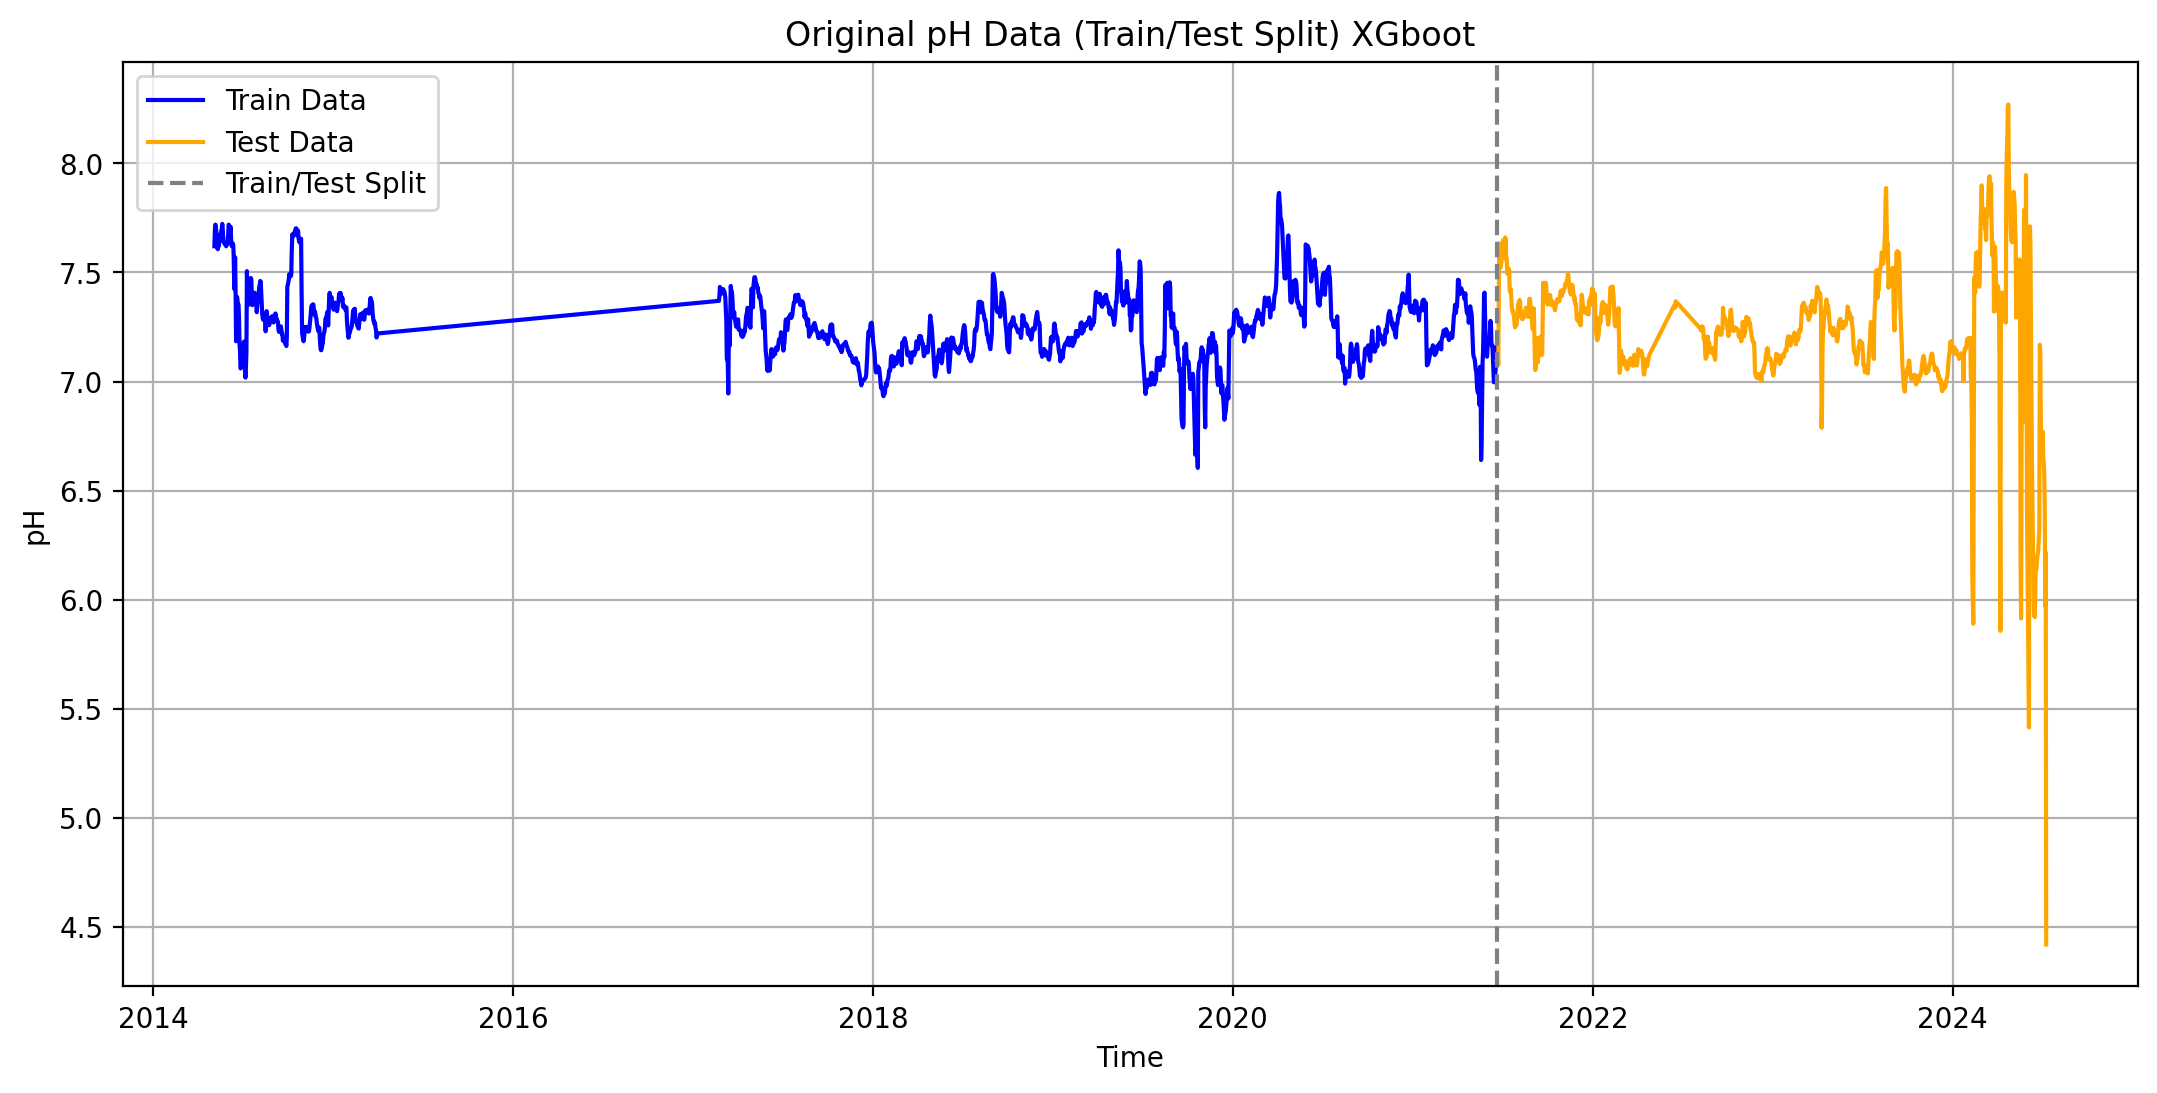

In [ ]:
plt.figure(figsize=(13, 6))
y_inv = scaler.inverse_transform(y) #กลับค่า y เป็นสเกลจริง

y_train_inv = y_inv[:split_at]
y_test_inv = y_inv[split_at:]

plt.plot(y.index[:split_at], y_train_inv, label="Train Data", color='blue')
plt.plot(y.index[split_at:], y_test_inv, label="Test Data", color='orange')
plt.axvline(x=y.index[split_at], color='gray', linestyle='--', label='Train/Test Split') #เส้นเเบ่ง
plt.title("Original pH Data (Train/Test Split) XGboot")
plt.xlabel("Time")
plt.ylabel("pH")
plt.legend()
plt.grid(True)
plt.show()


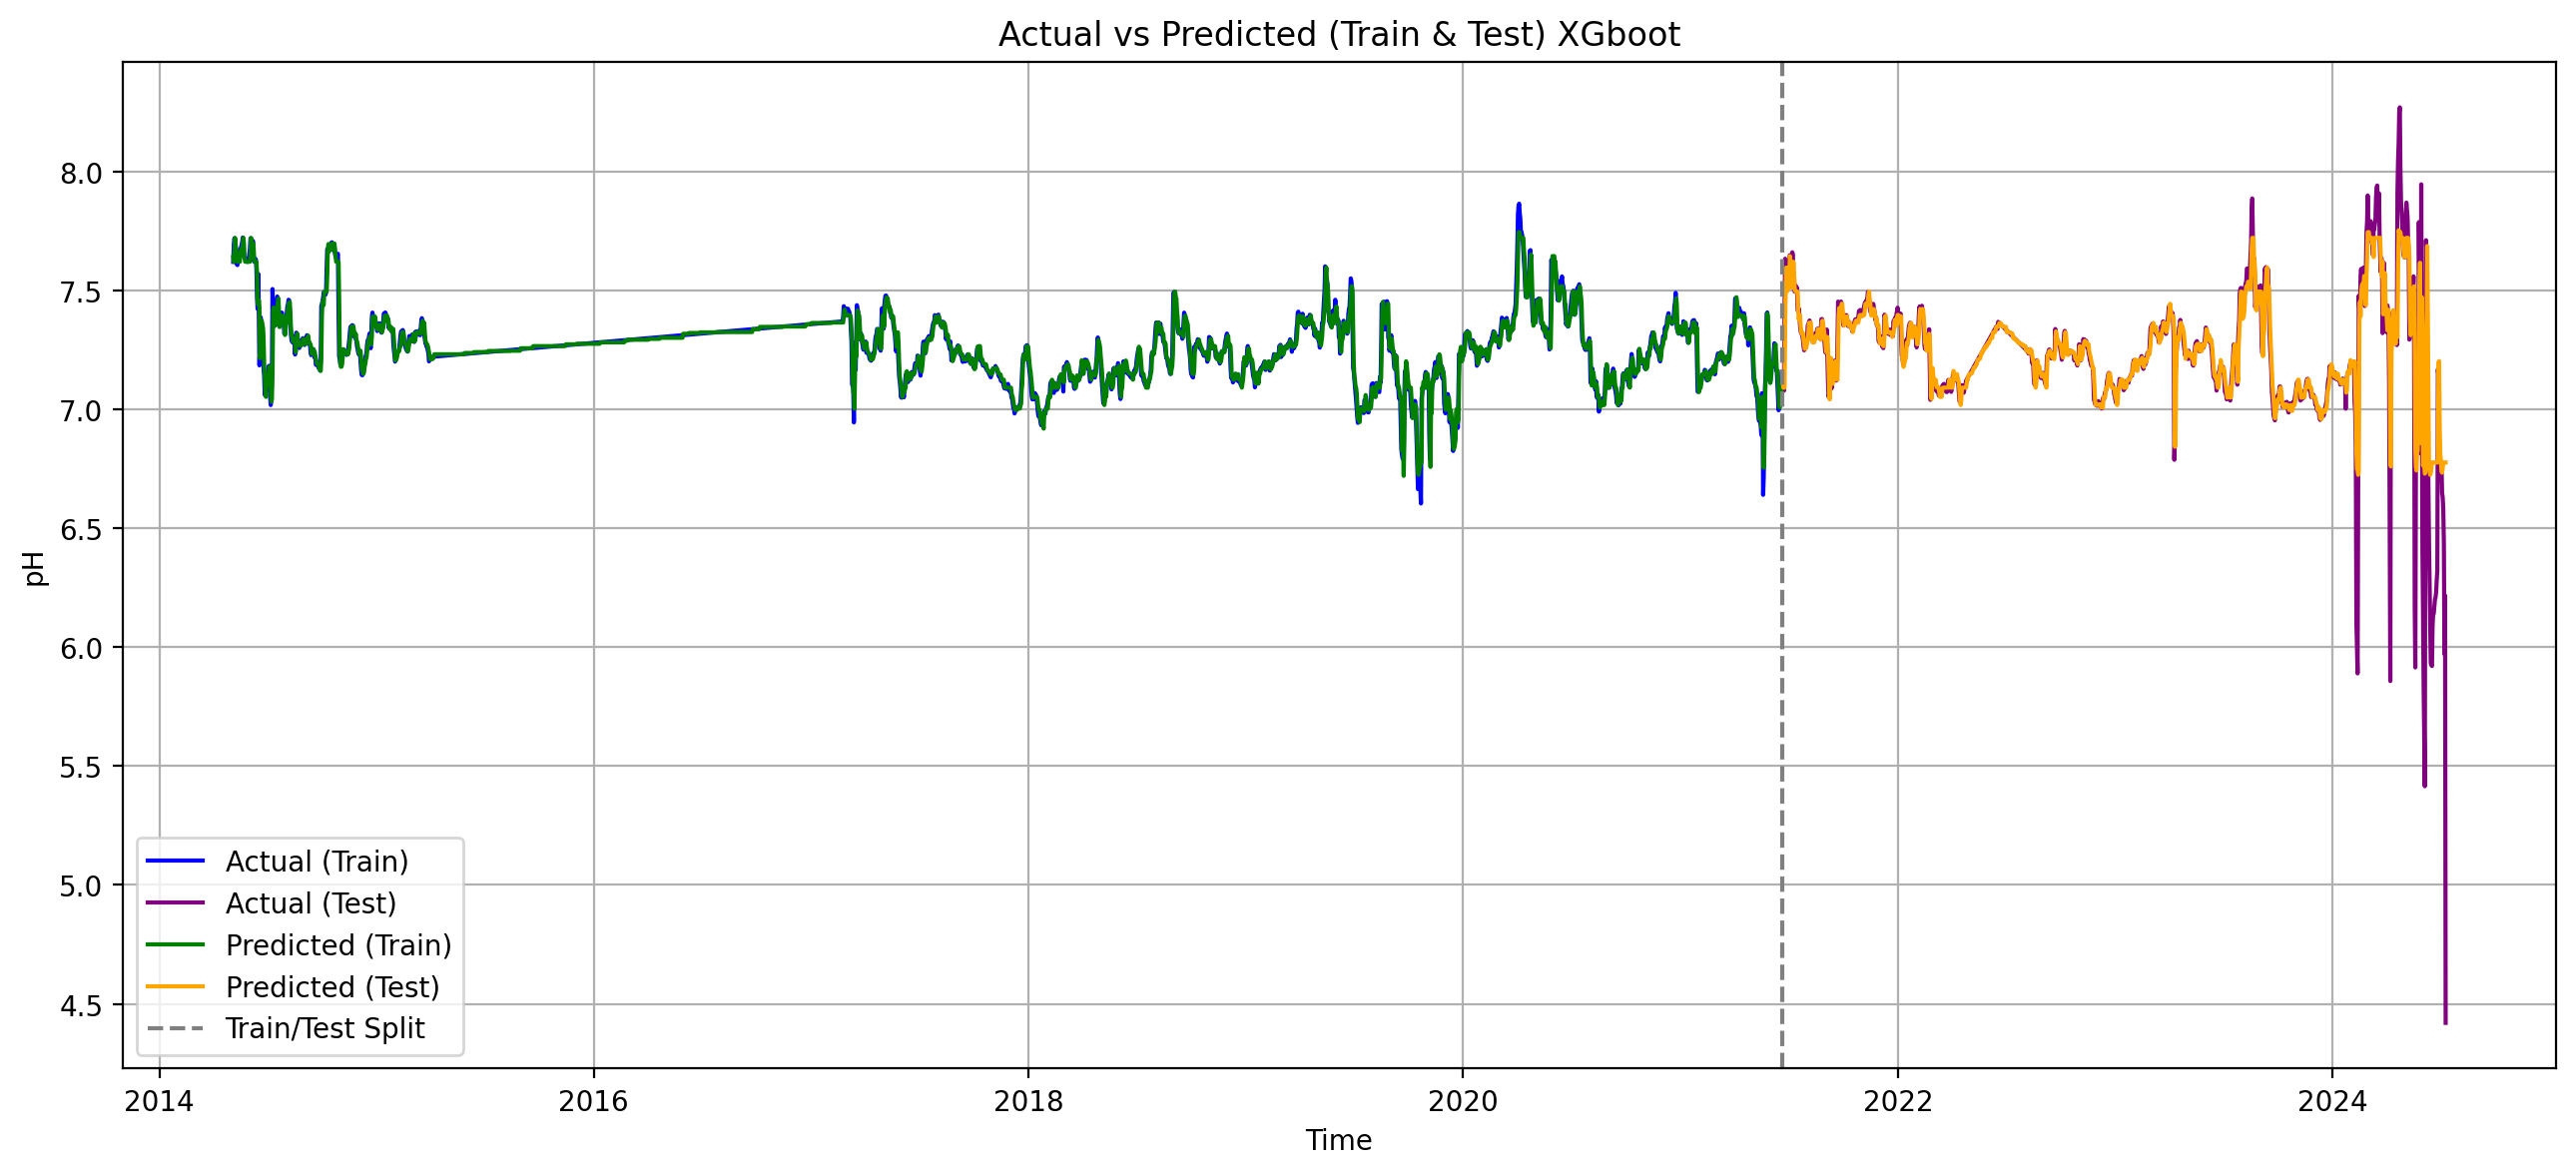

In [ ]:
plt.figure(figsize=(13, 6))
y_all = scaler.inverse_transform(y).ravel()
y_pred_train = best_xgb_regressor.predict(X_train1)
y_pred_train_inv = scaler.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()

# ค่าทำนายช่วงเทส
y_pred_test = best_xgb_regressor.predict(X_test1)
y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()

# สร้างค่าทำนายรวม
y_pred_combined = np.full_like(y_all, np.nan)
y_pred_combined[:split_at] = y_pred_train_inv
y_pred_combined[split_at:] = y_pred_test_inv


plt.plot(y.index[:split_at], y_all[:split_at], color='blue', label='Actual (Train)')
plt.plot(y.index[split_at:], y_all[split_at:], color='purple', label='Actual (Test)')
plt.plot(y.index[:split_at], y_pred_combined[:split_at], color='green', label='Predicted (Train)')
plt.plot(y.index[split_at:], y_pred_combined[split_at:], color='orange', label='Predicted (Test)')
plt.axvline(x=y.index[split_at], color='gray', linestyle='--', label='Train/Test Split')
plt.title("Actual vs Predicted (Train & Test) XGboot")
plt.xlabel("Time")
plt.ylabel("pH")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 1. ย้อนการสเกลของค่าที่ทำนายและค่าจริง
y_pred_scaled = best_xgb_regressor.predict(X_test1)
y_pred_original = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

# สมมติว่าคุณมีค่าจริง y_test1 ที่ถูกสเกลไว้ด้วย คุณควรย้อนการแปลงค่าจริงเหล่านั้น
y_test_original = scaler.inverse_transform(y_test1)

# 2. สร้าง DataFrame เพื่อความสะดวกในการเปรียบเทียบ
results_df = pd.DataFrame({
    "Predicted": y_pred_original.flatten(),
    "Actual": y_test_original.flatten()
})

# 3. พิมพ์ผลลัพธ์การเปรียบเทียบ
print("การเปรียบเทียบระหว่างค่าที่ทำนายและค่าจริง:")
print(results_df)

การเปรียบเทียบระหว่างค่าที่ทำนายและค่าจริง:
      Predicted    Actual
0      7.104370  7.106042
1      7.122859  7.109792
2      7.111060  7.078264
3      7.112723  7.419549
4      7.429402  7.633403
...         ...       ...
1112   6.761100  5.970347
1113   6.761100  6.217419
1114   6.761100  4.419900
1115   6.761100  2.082611
1116   6.761100  2.773056

[1117 rows x 2 columns]


## no.2

In [ ]:
 # ช่วงที่ 2
X_train2, X_test2 = X[9:split_at+9], np.concatenate((X[:9], X[split_at+9:]), axis=0)
y_train2, y_test2 = y[9:split_at+9], np.concatenate((y[:9], y[split_at+9:]), axis=0)

In [ ]:
X

,pH_lag_1,pH_lag_2,pH_lag_3,pH_lag_4,pH_lag_5,pH_lag_6,pH_lag_7,day,month,year,season,day_month_interaction
0,0.891379,0.854983,0.922342,1.000000,1.000000,1.000000,1.000000,0.133333,0.363636,0.0,0.333333,0.064690
1,0.894948,0.825437,0.804453,0.887909,0.899207,0.908436,0.940215,0.166667,0.363636,0.0,0.333333,0.078167
2,0.906873,0.831173,0.764613,0.774421,0.798414,0.816872,0.854125,0.200000,0.363636,0.0,0.333333,0.091644
3,0.910997,0.850338,0.772347,0.736068,0.696365,0.725308,0.768035,0.233333,0.363636,0.0,0.333333,0.105121
4,0.908696,0.856966,0.798189,0.743514,0.661877,0.632603,0.681945,0.266667,0.363636,0.0,0.333333,0.118598
...,...,...,...,...,...,...,...,...,...,...,...,...
3716,0.703047,0.560942,0.425808,0.415836,0.410914,0.355234,0.333547,0.200000,0.545455,1.0,0.666667,0.129380
3717,0.628332,0.522776,0.407956,0.409912,0.373922,0.373289,0.333996,0.233333,0.545455,1.0,0.666667,0.148248
3718,0.668264,0.402703,0.356491,0.392726,0.368596,0.339684,0.350972,0.266667,0.545455,1.0,0.666667,0.167116
3719,0.377751,0.466876,0.194580,0.343182,0.353142,0.334846,0.319376,0.300000,0.545455,1.0,0.666667,0.185984


In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train2, y_train2, X_test2, y_test2)

[I 2024-10-14 16:18:00,922] A new study created in memory with name: no-name-f708dde8-6c85-4a4f-8907-12b12f3a0e38
<ipython-input-47-44abec34af9d>:50: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.2),
<ipython-input-47-44abec34af9d>:54: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
<ipython-input-47-44abec34af9d>:55: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 

Best hyperparameters:  {'learning_rate': 0.19956907558523704, 'max_depth': 4, 'n_estimators': 1582, 'min_child_weight': 10, 'subsample': 0.9736052392702996, 'colsample_bytree': 0.8404930061136235, 'gamma': 0.0005412637453596548, 'alpha': 4.2097080443862536e-05, 'lambda': 0.00030871281367500573}
Test set performance:


R2: 0.5031755369131974
MAE: 0.010391978279028762
RMSE: 0.04042214802575557
MSE: 0.0016339500510160947



ความสำคัญของตัวแปร:
                   Feature  Importance
0                pH_lag_1    0.603200
1                pH_lag_2    0.185052
10                 season    0.045847
7                     day    0.028879
11  day_month_interaction    0.026486
3                pH_lag_4    0.021043
5                pH_lag_6    0.017538
9                    year    0.017246
2                pH_lag_3    0.015260
6                pH_lag_7    0.013903
8                   month    0.013421
4                pH_lag_5    0.012125


## no.3

In [ ]:
# ช่วงที่ 3
X_train3, X_test3 = X[99:split_at+99], np.concatenate((X[:99], X[split_at+99:]), axis=0)
y_train3, y_test3 = y[99:split_at+99], np.concatenate((y[:99], y[split_at+99:]), axis=0)

In [ ]:
study = optuna.create_study(direction='minimize', sampler=TPESampler())
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
best_xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=0,
    **study.best_params
)
regression_model(best_xgb_regressor, X_train3, y_train3, X_test3, y_test3)

[I 2024-10-14 16:18:29,091] A new study created in memory with name: no-name-6e34b9d5-85be-4d02-bd0b-d99d216fd91d
<ipython-input-47-44abec34af9d>:50: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.2),
<ipython-input-47-44abec34af9d>:54: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
<ipython-input-47-44abec34af9d>:55: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 

Best hyperparameters:  {'learning_rate': 0.19963158604632555, 'max_depth': 7, 'n_estimators': 1422, 'min_child_weight': 3, 'subsample': 0.9720636374263139, 'colsample_bytree': 0.7767171122648466, 'gamma': 5.958697622621074e-06, 'alpha': 0.0013531839208909872, 'lambda': 0.08301166786861182}
Test set performance:


R2: 0.5162649879058725
MAE: 0.011319261610870709
RMSE: 0.040508337775365506
MSE: 0.0016409254293231043



ความสำคัญของตัวแปร:
                   Feature  Importance
0                pH_lag_1    0.813763
1                pH_lag_2    0.093527
7                     day    0.012917
8                   month    0.012065
2                pH_lag_3    0.010295
10                 season    0.009438
11  day_month_interaction    0.009214
9                    year    0.008709
6                pH_lag_7    0.008373
3                pH_lag_4    0.008255
4                pH_lag_5    0.007449
5                pH_lag_6    0.005995
